# Turnover Prediction: Decision Tree Analysis  
The primary objective of this analysis is to evaluate a suite of machine learning techniques—including Logistic Regression, Decision Tree Analysis, Random Forest, AdaBoost, Gradient Boosting, and XGBoost—to determine the optimal predictive model for employee attrition. Additionally, this study aims to isolate and rank key workforce variables to uncover the critical drivers influencing employee retention versus turnover.
The dataset is available at https://www.kaggle.com/datasets/mfaisalqureshi/

1.   List item
2.   List item

hr-analytics-and-job-prediction?select=HR_comma_sep.csv


**Variable	Description**

**satisfaction_level**	Employee-reported job satisfaction level [0–1]

**last_evaluation**	Score of employee's last performance review [0–1]

**number_project**	Number of projects employee contributes to
average_monthly_hours	Average number of hours employee worked per month

**time_spend_company**	How long the employee has been with the company (years)

**Work_accident**	Whether or not the employee experienced an accident while at work

**left**	Whether or not the employee left the company
promotion_last_5years	Whether or not the employee was promoted in the last 5 years

**Department	**The employee's department
salary	The employee's salary (U.S. dollars)


**Target variable = 'left' (or Turnover)**

**1** indicates that the employee left the company.

**0** indicates that the employee stayed (did not leave)

In [1]:
# =========================================================
# 1. CORE DATA HANDLING
# =========================================================
import numpy as np
import pandas as pd
import math

pd.set_option('display.max_columns', None)

# =========================================================
# 2. STATISTICAL ANALYSIS
# =========================================================
from scipy import stats
from scipy.stats import pointbiserialr
from statsmodels.api import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

# =========================================================
# 3. PREPROCESSING / ENCODING
# =========================================================
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler

# =========================================================
# 4. VISUALIZATION
# =========================================================
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# 5. MODELING ALGORITHMS
# =========================================================
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier, XGBRegressor, plot_importance

# =========================================================
# 6. MODEL SELECTION & EVALUATION
# =========================================================
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    roc_curve,
)

# =========================================================
# 7. UTILITIES
# =========================================================
import pickle  # for saving/loading fitted model objects as byte streams

In [2]:
# Load dataset into a dataframe
df0 = pd.read_csv("HR_capstone_dataset.csv")

# 1. Exploratory Data Analysis   

## 1.1 Inspect Structure     

  ### 1.1.1 Check Column Names for Errors

Rename the columns as needed. Standardize the column names so that they are all in snake_case

In [3]:
# Display all column names
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [4]:
# Rename column names (snake_case)
df0 = df0.rename(columns={'Work_accident': 'work_accident',
                          'average_montly_hours': 'average_monthly_hours',
                          'time_spend_company': 'tenure',
                          'Department': 'department'})

# Display all column names after the update
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'tenure', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

 ### 1.1.2 Structure   

In [5]:
df0.shape

(14999, 10)

Rows=14999
Columns = 10

  ### 1.1.3 Variable Types  

In [6]:
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_monthly_hours  14999 non-null  int64  
 4   tenure                 14999 non-null  int64  
 5   work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


Since salary and department have different structures, it is best practice to handle them slightly differently during encoding step:

**salary** is Ordinal: It has an inherent order (e.g., low < medium < high). It is usually best to use Ordinal Encoding (assigning 0, 1, 2) to preserve this relationship.

**department** is Nominal: It has no natural rank (e.g., Sales vs. IT). It is typically best to use One-Hot Encoding (creating dummy variables) or Target Encoding.

  ### 1.1.4 Unique Values for All Variables

In [7]:
df0.nunique()

,0
satisfaction_level,92
last_evaluation,65
number_project,6
average_monthly_hours,215
tenure,8
work_accident,2
left,2
promotion_last_5years,2
department,10
salary,3


### 1.1.5 Overall Structure

In [8]:
df0.head(5)

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


***Note 1***

Salary and department are object type. However, it is highly recommended to keep them as object types for Exploratory Data Analysis (EDA) and encode them later, right before model building.

**1.** Visualizations and Tables Are Easier to Read. If you leave them as text, your plots and summary tables will automatically use readable labels like "sales", "engineering", "low", and "high". If you encode them into numbers (like 0, 1, 2) before EDA, your charts will just show numbers, forcing you to constantly remember which number represents which department.

**2.** Grouping and Aggregating is Intuitive

**3.** Understanding the Distribution of CategoriesLeaving them as strings allows you to easily count categories (df['department'].value_counts()) and check for spelling errors, rare categories, or anomalies before any mathematical transformation takes place.

***Note 2***

Target variable = 'left' (or Turnover)

1 indicates that the employee left the company.

0 indicates that the employee stayed (did not leave)

You need not to change the type of Target Variable. Instead, if you want to know the name of the category on plots or table, you can temporarily map the labels directly inside your visualization code. This keeps your raw data numerical but makes your charts highly readable.
Example: ax = sns.countplot(data=df, x='salary', hue=df['left'].map({0: 'Stayed', 1: 'Left'}))


  ## 1.2 Missing Value Analysis

In [9]:
# Check for Missing Values across all columns
df0.isnull().sum()

,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_monthly_hours,0
tenure,0
work_accident,0
left,0
promotion_last_5years,0
department,0
salary,0


  ## 1.3 Duplicate Case Analysis

In [10]:
# Check for number of duplicated cases
df0.duplicated().sum()


np.int64(3008)

In [11]:
# Inspect some rows containing duplicates as needed
df0[df0.duplicated()]

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


**Note:**
This dataset contains 3,008 fully identical rows (≈20% of the data). The standard and correct practice is to remove them before modeling.
Why drop them?
They are exact copies across all columns (not partial matches).
Keeping them artificially inflates sample size and can bias model metrics (especially accuracy, precision/recall on the minority class left=1).
Logistic Regression (and almost every other model) assumes independent observations. Exact duplicates violate that assumption.
After removal you still have a healthy dataset: 11,991 unique rows.

In [12]:
# 3. Drop duplicates (keep the first occurrence)
df = df0.drop_duplicates(keep='first')   # or keep='last' — doesn't matter much here
print("After dropping duplicates:", df.shape)

After dropping duplicates: (11991, 10)


**Reset Index - df.reset_index(drop=True)**

In pandas, df.reset_index(drop=True) resets the row labels (the index) of DataFrame back to a default sequential order starting from 0, 1, 2, 3, etc. Here is exactly what it does:
1. Why we need it after dropping duplicates? When we drop duplicate rows, pandas removes those rows entirely but leaves the original index numbers untouched.For example, if rows 1 and 2 are duplicates, pandas will delete row

2. The index will then skip from 1 straight to 3 (e.g., 0, 1, 3, 4...). By resetting the index, you heal those "gaps" so your rows are numbered consecutively again. With drop=True: It discards the old, broken index entirely.

In [13]:
df = df.reset_index(drop=True)
df.shape

(11991, 10)

In [14]:
# Verification after droping duplicates
print("Duplicates:", df.duplicated().sum())
print(df['left'].value_counts(normalize=True))
# left ≈ 16.6% (still imbalanced, which is normal for this dataset)

Duplicates: 0
left
0    0.833959
1    0.166041
Name: proportion, dtype: float64


## 1.4 Outlier Detection

Visualize continuous variables like average_monthly_hours) with a boxplot, then compute the IQR (Q3-Q1), and the lower/upper bounds (Q1-1.5*IQR, Q3+1.5*IQR) to count how many rows fall outside them. Since logistic regression is sensitive to outliers, you'll likely want a version of the data with these rows removed for that model, even if you keep them for the tree-based models later.

**Continuous Feature Grouping.**

In [15]:
# Continuous variables
continuous_vars = [
    'satisfaction_level',
    'last_evaluation',
    'number_project',
    'average_monthly_hours',
    'tenure'
]


### 1.4.1 Boxplots     

In [16]:
def plot_continuous_boxplots(dataframe, variables_list, num_columns=3):
    """Generates a single figure containing individual boxplots for a list of

    continuous variables.
    """
    num_vars = len(variables_list)
    num_rows = math.ceil(num_vars / num_columns)

    # 1. Initialize the single figure window
    fig, axes = plt.subplots(
        nrows=num_rows,
        ncols=num_columns,
        figsize=(5 * num_columns, 4 * num_rows),
    )

    # Flatten the axes array to make indexing simple, even if it is 1D or 2D
    if num_vars == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # 2. Loop through and plot each variable
    for i, var in enumerate(variables_list):
        sns.boxplot(data=dataframe, y=var, ax=axes[i], color="skyblue")
        axes[i].set_title(f"Distribution of {var}", fontsize=11, fontweight="bold")
        axes[i].set_ylabel("")  # Clear y-label to avoid repetition with title
        axes[i].grid(axis="y", linestyle="--", alpha=0.7)  # Add a subtle grid

    # 3. Clean up empty subplots if the grid has leftover slots
    for j in range(num_vars, len(axes)):
        fig.delaxes(axes[j])

    # 4. Adjust layout spacing and render
    plt.tight_layout()
    plt.show()




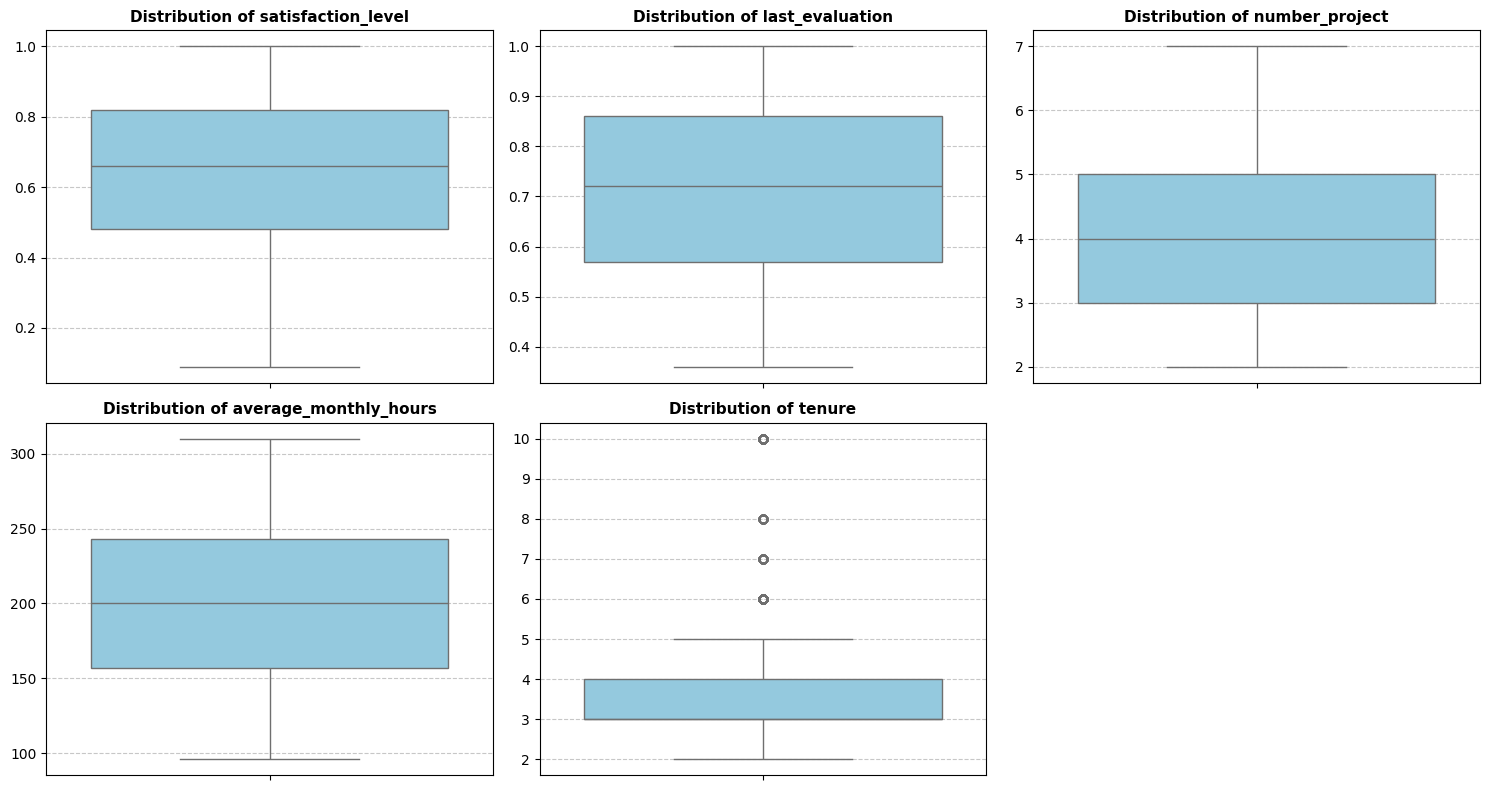

In [17]:
# Call the function to draw the figure
plot_continuous_boxplots(dataframe=df, variables_list=continuous_vars)

Boxplots show outliers for tenure

### 1.4.2 IQR Method  

The Interquartile Range (IQR) Method is a popular and robust statistical technique used to detect outliers in a dataset. It is highly effective because it relies on percentiles, making it immune to the influence of extreme values (unlike methods that use the mean or standard deviation).

1. The Core ComponentsThe method divides a sorted dataset into four equal parts using quartiles:
First Quartile (Q1 / 25th Percentile): The middle number between the smallest value and the median. 25% of the data falls below this point.
Third Quartile (Q3/ 75th Percentile): The middle number between the median and the highest value. 75% of the data falls below this point.
Interquartile Range (\(\text{IQR}\)): The distance between the 75th and 25th percentiles (IQR = Q3 - Q1). This represents the spread of the middle 50% of your data.2.

Establishing the Thresholds (The "Fences")To define what constitutes an outlier, the method builds an artificial "boundary" or fence around the data using a standard multiplier of \(1.5\):
Lower Limit Threshold=Q1-(1.5 * IQR)
Upper Limit Threshold=Q_(1.5 *IQR)

3. Outlier Identification: Any data point that falls outside these calculated thresholds is officially flagged as an outlier:An outlier is any value <Lower Limit OR >Upper Limit.
Why use 1.5?
The 1.5 multiplier was established by statistician John Tukey. In a perfectly standard normal distribution, data points falling outside  1.5 * IQR represent roughly 0.7\% of the data, marking them as mathematically unusual or extreme.

In [18]:
# 1. Define the base function first
def check_outliers(df, column_name):
    """Computes IQR and identifies outliers for a specific numeric column.

    Prints a metrics summary and returns a DataFrame subset containing the
    outliers.
    """
    percentile25 = df[column_name].quantile(0.25)
    percentile75 = df[column_name].quantile(0.75)
    iqr = percentile75 - percentile25

    lower_limit = percentile25 - (1.5 * iqr)
    upper_limit = percentile75 + (1.5 * iqr)

    outlier_df = df[
        (df[column_name] > upper_limit) | (df[column_name] < lower_limit)
    ]

    print(f"=== Outlier Analysis for: '{column_name}' ===")
    print(f"Lower 25 percentile : {percentile25}")
    print(f"Upper 75 percentile : {percentile75}")
    print(f"IQR                  : {iqr}")
    print(f"Lower limit threshold: {lower_limit}")
    print(f"Upper limit threshold: {upper_limit}")
    print(f"Number of outlier rows found: {len(outlier_df)}")
    print("=" * 40 + "\n")

    return outlier_df


# 2. Define the runner function that uses the base function
def check_all_outliers(df, variables_list):
    """Loops through a list of continuous variables and uses the check_outliers

    function to analyze and store outlier subsets for all of them in one go.
    """
    all_outliers_dict = {}
    for col in variables_list:
        outlier_data = check_outliers(df, col)
        all_outliers_dict[col] = outlier_data
    return all_outliers_dict



In [19]:
# Run the analysis for all variables at once
outliers_by_feature = check_all_outliers(df, continuous_vars)

=== Outlier Analysis for: 'satisfaction_level' ===
Lower 25 percentile : 0.48
Upper 75 percentile : 0.82
IQR                  : 0.33999999999999997
Lower limit threshold: -0.030000000000000027
Upper limit threshold: 1.33
Number of outlier rows found: 0

=== Outlier Analysis for: 'last_evaluation' ===
Lower 25 percentile : 0.57
Upper 75 percentile : 0.86
IQR                  : 0.29000000000000004
Lower limit threshold: 0.1349999999999999
Upper limit threshold: 1.295
Number of outlier rows found: 0

=== Outlier Analysis for: 'number_project' ===
Lower 25 percentile : 3.0
Upper 75 percentile : 5.0
IQR                  : 2.0
Lower limit threshold: 0.0
Upper limit threshold: 8.0
Number of outlier rows found: 0

=== Outlier Analysis for: 'average_monthly_hours' ===
Lower 25 percentile : 157.0
Upper 75 percentile : 243.0
IQR                  : 86.0
Lower limit threshold: 28.0
Upper limit threshold: 372.0
Number of outlier rows found: 0

=== Outlier Analysis for: 'tenure' ===
Lower 25 percenti

The IQR method identified 824 outliers

### 1.4.3 Z-Score Method  

In [20]:
import numpy as np
import pandas as pd
from scipy import stats


# 1. Your base Z-score function
def check_outliers_zscore(df1, column_name, threshold=3):
    """Computes Z-scores and identifies rows outside the specified absolute

    threshold (default |z| > 3).

    Prints a detailed diagnostic log and returns the outlier rows.
    """
    # Calculate absolute Z-scores for the column
    z_scores = np.abs(stats.zscore(df1[column_name]))

    # Filter out rows that break past the threshold limit
    outlier_df = df1[z_scores > threshold]

    # Print clean, structured summary logs
    print(f"=== Z-score Outlier Analysis for: '{column_name}' ===")
    print(f"Applied Threshold    : |z| > {threshold}")
    print(f"Data Mean Value      : {df1[column_name].mean():.4f}")
    print(f"Data Std Dev Value   : {df1[column_name].std():.4f}")
    print(f"Max Absolute Z-score : {z_scores.max():.4f}")
    print(f"Number of outlier rows found: {len(outlier_df)}")
    print("=" * 45 + "\n")

    return outlier_df


# 2. The runner function to process all columns in one go
def check_all_outliers_zscore(df1, variables_list, threshold=3):
    """Loops through a list of continuous variables and uses Z-score method

    to identify and store outliers for all of them in one go.
    """
    all_z_outliers_dict = {}

    for col in variables_list:
        outlier_data = check_outliers_zscore(df1, col, threshold)
        all_z_outliers_dict[col] = outlier_data

    return all_z_outliers_dict


In [21]:
# Call the function
z_outliers_by_feature = check_all_outliers_zscore(df, continuous_vars)

=== Z-score Outlier Analysis for: 'satisfaction_level' ===
Applied Threshold    : |z| > 3
Data Mean Value      : 0.6297
Data Std Dev Value   : 0.2411
Max Absolute Z-score : 2.2387
Number of outlier rows found: 0

=== Z-score Outlier Analysis for: 'last_evaluation' ===
Applied Threshold    : |z| > 3
Data Mean Value      : 0.7167
Data Std Dev Value   : 0.1683
Max Absolute Z-score : 2.1189
Number of outlier rows found: 0

=== Z-score Outlier Analysis for: 'number_project' ===
Applied Threshold    : |z| > 3
Data Mean Value      : 3.8029
Data Std Dev Value   : 1.1632
Max Absolute Z-score : 2.7486
Number of outlier rows found: 0

=== Z-score Outlier Analysis for: 'average_monthly_hours' ===
Applied Threshold    : |z| > 3
Data Mean Value      : 200.4735
Data Std Dev Value   : 48.7278
Max Absolute Z-score : 2.2478
Number of outlier rows found: 0

=== Z-score Outlier Analysis for: 'tenure' ===
Applied Threshold    : |z| > 3
Data Mean Value      : 3.3649
Data Std Dev Value   : 1.3302
Max Absolut

The Z scores method  identified 188 outliers for the feature 'tenure'

The IQR Method flagged around 824 outliers for tenure because the middle 50% of your data is tightly packed, making the fences narrow.
The Z-Score Method will likely flag significantly fewer (or even zero) outliers for tenure. Because Z-score relies on the standard deviation, a heavily right-skewed distribution artificially inflates the standard deviation, stretching the threshold limit out much further.

**Drop or Cap**

Whether an employee has been there for 6 years, 8 years, or 10 years, they all fall into the same "high tenure" bucket during a split. Capping or dropping them adds absolutely no performance benefit to these models.

1. Zero Impact on Your Best Models (Trees & Boosting)

The algorithms for Decision Trees, Random Forests, AdaBoost, Gradient Boosting, and XGBoost split data using hard thresholds (e.g., tenure > 4.5 years). They do not calculate distances or variance. Whether an employee has been there for 6 years, 8 years, or 10 years, they all fall into the same "high tenure" bucket during a split. Capping or dropping them adds absolutely no performance benefit to these models.

2. They Represent Crucial Business Realities

An employee who has a tenure of 5 to 10 years isn't a "data error" or a "fluke"—they are your senior staff. In HR analytics, understanding why long-term, loyal employees suddenly choose to leave or stay is arguably the most valuable insight the model can provide. If you drop these rows, you erase your most important data on senior retention.

However, logistic model on list will get confused by these outliers , because it relies on linear relationships and can be heavily skewed by the variance in unscaled, right-skewed columns like tenure.

Therefore, instead of dropping or capping the data permanently in our dataframe, we will handle it dynamically during this stage:

1. Leave the raw dataset intact. Do not drop or cap any rows.

2. Apply Standard Scaling or Robust Scaling to our continuous features only when feeding them into our Logistic Regression model. (RobustScaler uses the median and IQR, automatically neutralizing the impact of outliers for linear models).

3. Feed the unscaled data directly into our Random Forest and Boosting models.

## 1.5 Data Visualization

### 1.5.1 Normality

**Histograms**

In [22]:
def plot_continuous_histograms(dataframe, variables_list, num_columns=3):
    """Generates a single figure containing individual histograms/density plots

    for a list of continuous variables.
    """
    num_vars = len(variables_list)
    num_rows = math.ceil(num_vars / num_columns)

    # 1. Initialize the single figure window
    fig, axes = plt.subplots(
        nrows=num_rows,
        ncols=num_columns,
        figsize=(5 * num_columns, 4 * num_rows),
    )

    # Flatten the axes array to make indexing uniform
    if num_vars == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # 2. Loop through and plot each variable
    for i, var in enumerate(variables_list):
        # Using histplot with kde=True to show the distribution curve
        sns.histplot(
            data=dataframe,
            x=var,
            ax=axes[i],
            kde=True,
            color="purple",
            bins=20,
        )

        axes[i].set_title(
            f"Distribution of {var}", fontsize=11, fontweight="bold"
        )
        axes[i].set_xlabel("")  # Clear x-label to prevent clutter
        axes[i].set_ylabel("Frequency", fontsize=10)
        axes[i].grid(axis="y", linestyle="--", alpha=0.5)

    # 3. Clean up any empty subplots in the grid layout
    for j in range(num_vars, len(axes)):
        fig.delaxes(axes[j])

    # 4. Optimize spacing and display
    plt.tight_layout()
    plt.show()


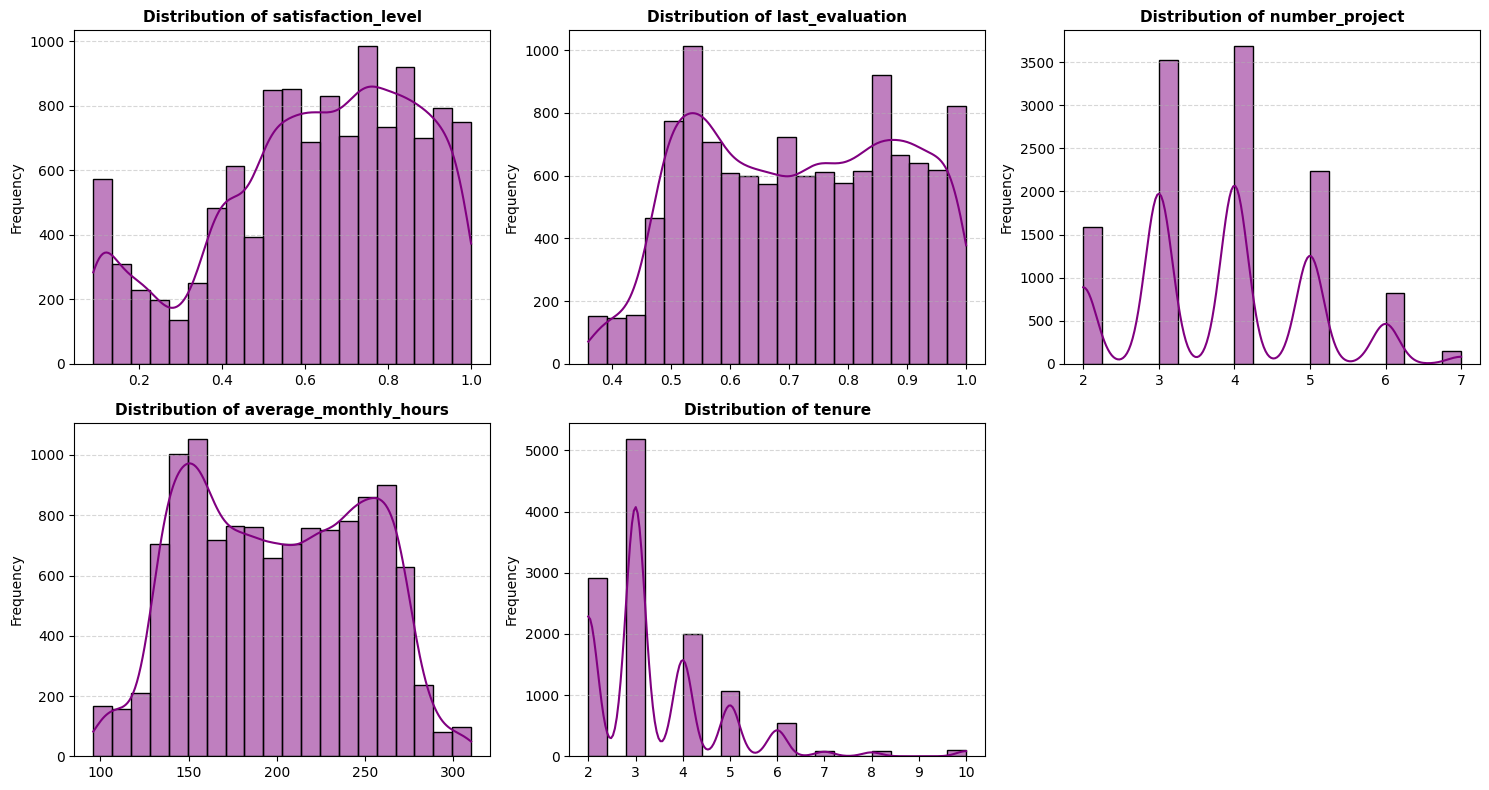

In [23]:
# call the function to plot histograms
plot_continuous_histograms(dataframe=df, variables_list=continuous_vars)

Non-normal independent variables are not a problem because logistic regression has no normality assumptions for predictor variables.Unlike linear regression (which looks for a bell curve in continuous data), logistic regression is designed to handle all types of skewed distributions, categorical fields, and binary inputs. Why Normality Doesn't Matter The Goal is Probability: Logistic regression focuses on a binary outcome (e.g., 0 for stayed, 1 for left). It maps continuous values onto a probability S-curve (the sigmoid function) between 0 and 1, meaning it doesn't care if the underlying feature has massive clusters at the low or high ends. The Error Structure is Different: Linear models assume errors (residuals) are normally distributed. Logistic models assume the variance follows a binomial distribution, meaning the traditional "bell curve check" is completely irrelevant here.

 ### 1.5.2 Visualizing the Target ('left')

In [24]:
# 1. Temporarily map the left column to text labels for clean summaries
attrition_counts = df["left"].map({0: "Stayed", 1: "Left"}).value_counts()
attrition_pct = (
    df["left"].map({0: "Stayed", 1: "Left"}).value_counts(normalize=True)
    * 100
)

# 2. Print out the figures with your requested titles
print(f"Number of people who stayed           : {attrition_counts['Stayed']}")
print(
    f"Number of people who left the company : {attrition_counts['Left']}"
)
print(
    f"Percentage of people who stayed       : {attrition_pct['Stayed']:.2f}%"
)
print(
    f"Percentage of people who left         : {attrition_pct['Left']:.2f}%"
)

Number of people who stayed           : 10000
Number of people who left the company : 1991
Percentage of people who stayed       : 83.40%
Percentage of people who left         : 16.60%


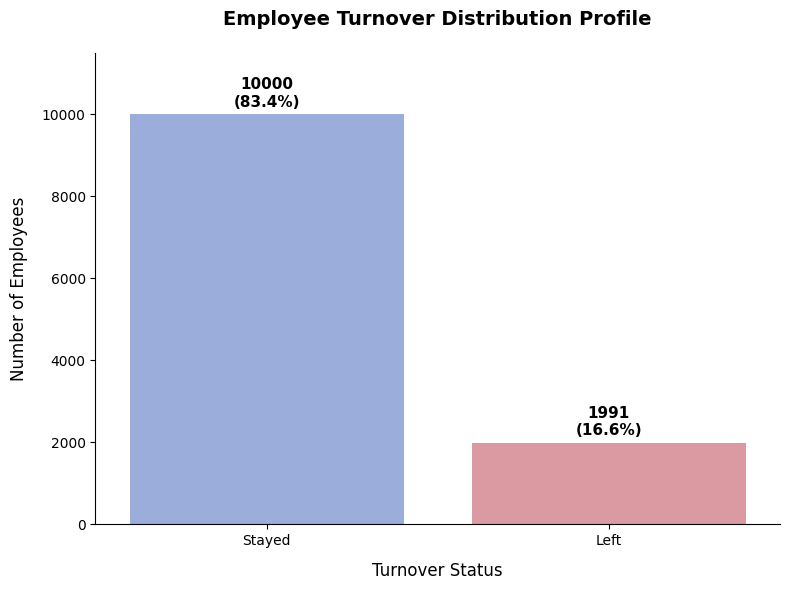

In [25]:
# 1. Calculate the values cleanly in one place (using your mapped strings)
eda_series = df["left"].map({0: "Stayed", 1: "Left"})
counts = eda_series.value_counts()
percentages = eda_series.value_counts(normalize=True) * 100

# 2. Setup the chart layout window
plt.figure(figsize=(8, 6))
custom_palette = {"Stayed": "#8FA9E6", "Left": "#E68F9A"}

# 3. Plot directly using the calculated data structures
ax = sns.barplot(
    x=counts.index,
    y=counts.values,
    palette=custom_palette,
    hue=counts.index,
    legend=False,
)

# 4. Annotate using the active percentages variables
for p in ax.patches:
    height = p.get_height()
    # Pull the correct index text ('Stayed' or 'Left') based on bar location
    bar_label = counts.index[int(p.get_x() + 0.5)]

    # Dynamic summary label
    label = f"{int(height)}\n({percentages[bar_label]:.1f}%)"

    ax.annotate(
        label,
        (p.get_x() + p.get_width() / 2.0, height),
        ha="center",
        va="center",
        xytext=(0, 15),
        textcoords="offset points",
        fontsize=11,
        fontweight="bold",
    )

# 5. Presentation fine-tuning
plt.title(
    "Employee Turnover Distribution Profile",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
plt.xlabel("Turnover Status", fontsize=12, labelpad=10)
plt.ylabel("Number of Employees", fontsize=12, labelpad=10)
plt.ylim(0, counts.max() * 1.15)

sns.despine()
plt.tight_layout()
plt.show()

**Class Imbalance:** As calculated, roughly 76% of employees stayed and 24% left. Logistic Regression algorithms natively try to maximize overall accuracy. With an imbalanced dataset, the model will bias heavily toward the majority class (Stayed = 0), resulting in poor recall for the employees who actually leave.

**Set Decison Tree/LogisticRegression(class_weight='balanced')**
When you set class_weight='balanced' in Logistic Regression/Decision Tree, you are telling the model to stop treating all mistakes equally and start caring more about the minority group (the people who left).

**The Core Problem It Solves:** Because our dataset has 76% people who stayed and only 24% who left, a standard Logistic Regression model discovers a "lazy" trick to get a high score: it can just guess that everyone stays. By doing this, it achieves a 76% accuracy score while being completely useless at actually catching the employees who are about to quit.

**How class_weight='balanced' Changes the Rules:** When you activate this setting, Python automatically calculates a penalty multiplier based on the class sizes.
It looks at the ratio of data: 76% stayed/24% left. Because people who leave are roughly 3 times rarer than people who stay, the algorithm assigns a 3x higher financial/mathematical penalty whenever the model misclassifies a person who left.

**The Real-World Analogy**

Imagine a security guard at an airport:
**Without class_weight (Standard Model)**: The guard gets evaluated purely on how many total people pass through smoothly. Since 99% of people are safe, the guard just lets everyone through without checking to maximize efficiency.
**With class_weight='balanced':** The supervisor tells the guard, "Missing a single security threat is 3 times worse than stopping an innocent person for questioning." The guard immediately becomes more alert, focuses heavily on finding the threats, and accepts that they will occasionally pull aside innocent people to be safe.


### 1.5.3 Avg. Monthly Hours by Number of Projects

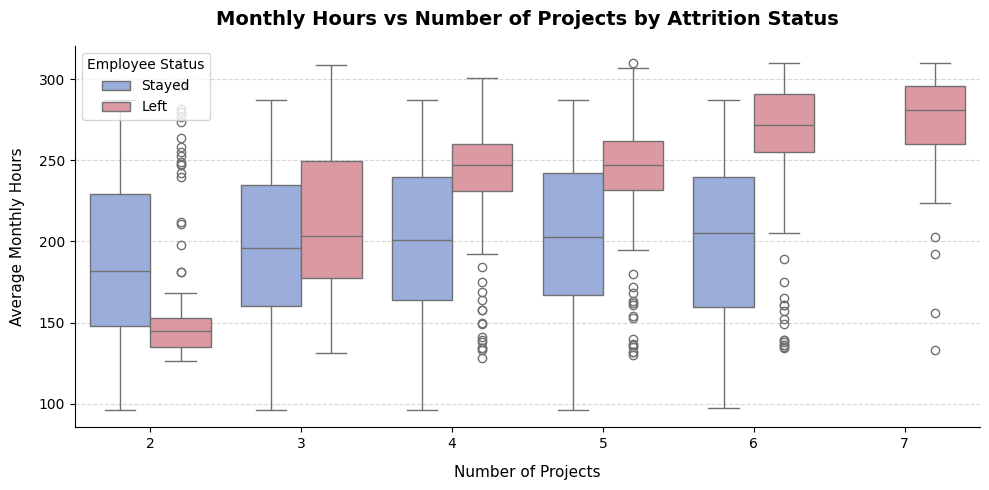

In [26]:
# 1. Create a temporary dataframe copy with mapped labels for clean execution
plot_df = df.copy()
plot_df["left_mapped"] = plot_df["left"].map({0: "Stayed", 1: "Left"})

# 2. Consistent palette configuration from your previous bar chart
consistent_palette = {"Stayed": "#8FA9E6", "Left": "#E68F9A"}

# 3. Initialize the plot layout window
plt.figure(figsize=(10, 5))

# 4. Draw the bivariate grouped boxplot using 'df' reference data
ax = sns.boxplot(
    data=plot_df,
    x="number_project",
    y="average_monthly_hours",
    hue="left_mapped",
    palette=consistent_palette,
    hue_order=["Stayed", "Left"],  # Keeps categorical columns uniform
    showfliers=True,
)

# 5. Fine-tune presentation labels, legend adjustments, and boundaries
plt.title(
    "Monthly Hours vs Number of Projects by Attrition Status",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Number of Projects", fontsize=11, labelpad=10)
plt.ylabel("Average Monthly Hours", fontsize=11, labelpad=10)

# The legend text handles itself automatically now thanks to the mapped data series
plt.legend(title="Employee Status", loc="upper left", frameon=True)
plt.grid(axis="y", linestyle="--", alpha=0.5)

sns.despine()
plt.tight_layout()
plt.show()



This figure reveals a powerful, non-linear relationship between work volume and employee attrition. It shows that employee turnover in this company is primarily driven by two polar opposite problems: extreme burnout and severe underutilization.

**1. The Burnout Zone (5, 6, and 7 Projects)Extreme Overwork:** As the number of projects climbs to 5, 6, and especially 7, a dramatic shift occurs.

Complete Attrition at 7 Projects: For employees with 7 projects, the blue box vanishes entirely. 100% of employees assigned to 7 projects left the company.

The Hours Explode: Look at the Y-axis for these cohorts. Employees leaving with 6 or 7 projects are working near or above 250 to 300 hours per month (over 60 hours a week). This is a signature of voluntary turnover due to workplace exhaustion and burnout.

**2. The Low-Engagement Trap:** Look closely at the cohort with only 2 projects. Paradoxically, a huge portion of this group chooses to leave (Left). These employees are not leaving because they are overworked; they are leaving because they are underworked, underutilized, or potentially disengaged. They are likely seeking positions with more responsibility and growth potential elsewhere.

### 1.5.4 Satisfaction Level and Turnover    

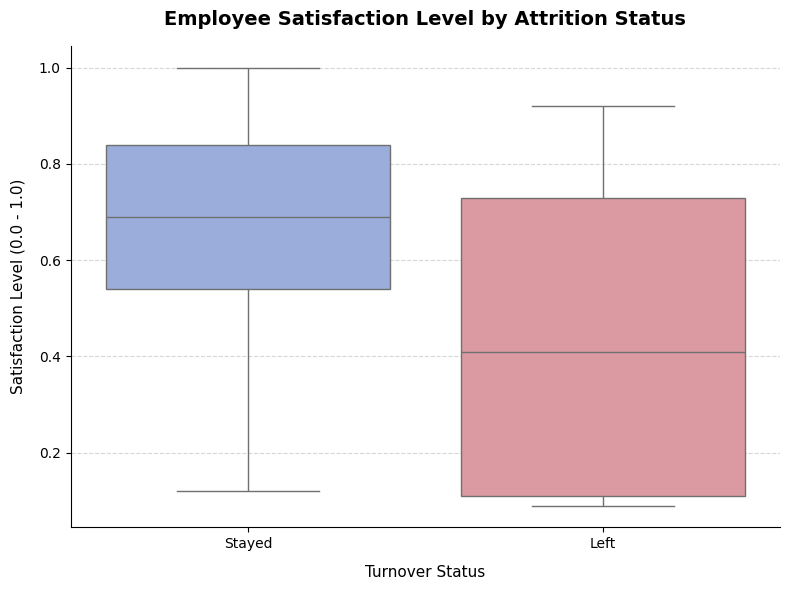

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a temporary dataframe copy with mapped labels
plot_df = df.copy()
plot_df["left_mapped"] = plot_df["left"].map({0: "Stayed", 1: "Left"})

# 2. Consistent palette configuration
consistent_palette = {"Stayed": "#8FA9E6", "Left": "#E68F9A"}

# 3. Initialize the plot layout window
plt.figure(figsize=(8, 6))

# 4. Draw the boxplot for satisfaction level
ax = sns.boxplot(
    data=plot_df,
    x="left_mapped",
    y="satisfaction_level",
    hue="left_mapped",
    palette=consistent_palette,
    order=["Stayed", "Left"],  # Ensures clean horizontal ordering
    legend=False,  # Legend is redundant since labels are on the x-axis
)

# 5. Fine-tune presentation labels and boundaries
plt.title(
    "Employee Satisfaction Level by Attrition Status",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Turnover Status", fontsize=11, labelpad=10)
plt.ylabel("Satisfaction Level (0.0 - 1.0)", fontsize=11, labelpad=10)
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Clean minimalist borders
sns.despine()
plt.tight_layout()
plt.show()


**The Retained Workforce (Stayed):** The median satisfaction level sits comfortably high (typically around 0.65 to 0.70), with the bulk of the data clustered in the upper half of the chart.

**The Departed Workforce (Left):** The entire box drops dramatically down the Y-axis. The median satisfaction level for those who left sits significantly lower (often hovering around 0.40). This visually confirms that a low satisfaction score is a massive baseline indicator of turnover risk.

**Independent Samples t test**

In [28]:

# 1. Isolate the satisfaction levels for both groups
satisfaction_stayed = df[df["left"] == 0]["satisfaction_level"]
satisfaction_left = df[df["left"] == 1]["satisfaction_level"]

# 2. Step 1: Run Levene's Test for Equal Variances
levene_stat, levene_p = stats.levene(satisfaction_stayed, satisfaction_left)

# Fixed: Corrected inline if-else syntax in Python
has_equal_variance = True if levene_p > 0.05 else False

# 3. Step 2: Run the appropriate Independent Samples t-test
t_stat, t_p = stats.ttest_ind(
    satisfaction_stayed, satisfaction_left, equal_var=has_equal_variance
)

# 4. Print clean, publication-ready statistical diagnostic logs
print("=== Independent Samples t-test: Satisfaction Level ===")
print(f"Mean Satisfaction (Stayed) : {satisfaction_stayed.mean():.4f}")
print(f"Mean Satisfaction (Left)   : {satisfaction_left.mean():.4f}")
print(
    f"Mean Difference            : {satisfaction_stayed.mean() - satisfaction_left.mean():.4f}"
)
print("-" * 50)
print(f"Levene's Test p-value      : {levene_p:.4e}")
print(f"Assumed Equal Variance?    : {has_equal_variance}")
print("-" * 50)
print(f"t-statistic                : {t_stat:.4f}")
print(f"t-test p-value             : {t_p:.4e}")
print("=" * 50 + "\n")

# Statistical conclusion printout
if t_p < 0.05:
    print(
        "CONCLUSION: Statistically Significant. The difference in satisfaction levels\n"
        "between employees who stayed and those who left is highly unlikely to be due to chance."
    )
else:
    print(
        "CONCLUSION: Not Statistically Significant. There is no structural difference\n"
        "in satisfaction levels between the two groups."
    )


=== Independent Samples t-test: Satisfaction Level ===
Mean Satisfaction (Stayed) : 0.6674
Mean Satisfaction (Left)   : 0.4403
Mean Difference            : 0.2271
--------------------------------------------------
Levene's Test p-value      : 7.1416e-21
Assumed Equal Variance?    : False
--------------------------------------------------
t-statistic                : 35.8893
t-test p-value             : 1.1940e-228

CONCLUSION: Statistically Significant. The difference in satisfaction levels
between employees who stayed and those who left is highly unlikely to be due to chance.


### 1.5.5 Last Evaluation and Turnover

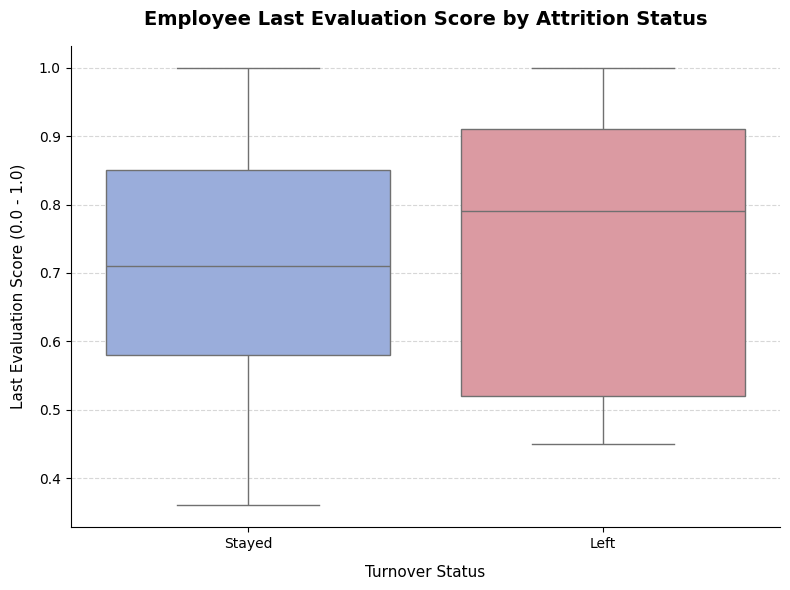

In [29]:
# 1. Create a temporary dataframe copy with mapped labels
plot_df = df.copy()
plot_df["left_mapped"] = plot_df["left"].map({0: "Stayed", 1: "Left"})

# 2. Consistent palette configuration (Muted Blue for Stayed, Soft Pink for Left)
consistent_palette = {"Stayed": "#8FA9E6", "Left": "#E68F9A"}

# 3. Initialize the plot layout window
plt.figure(figsize=(8, 6))

# 4. Draw the boxplot for last_evaluation
ax = sns.boxplot(
    data=plot_df,
    x="left_mapped",
    y="last_evaluation",
    hue="left_mapped",
    palette=consistent_palette,
    order=["Stayed", "Left"],
    legend=False,
)

# 5. Fine-tune presentation labels and boundaries
plt.title(
    "Employee Last Evaluation Score by Attrition Status",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Turnover Status", fontsize=11, labelpad=10)
plt.ylabel("Last Evaluation Score (0.0 - 1.0)", fontsize=11, labelpad=10)
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Clean minimalist borders
sns.despine()
plt.tight_layout()
plt.show()

In [30]:
# Independant Samples t test
# 1. Isolate the evaluation scores for both groups
evaluation_stayed = df[df["left"] == 0]["last_evaluation"]
evaluation_left = df[df["left"] == 1]["last_evaluation"]

# 2. Run Levene's Test for Equal Variances
levene_stat, levene_p = stats.levene(evaluation_stayed, evaluation_left)
has_equal_variance = True if levene_p > 0.05 else False

# 3. Run the appropriate Independent Samples t-test
t_stat, t_p = stats.ttest_ind(
    evaluation_stayed, evaluation_left, equal_var=has_equal_variance
)

# 4. Print clean, publication-ready statistical diagnostic logs
print("=== Independent Samples t-test: Last Evaluation Score ===")
print(f"Mean Evaluation (Stayed) : {evaluation_stayed.mean():.4f}")
print(f"Mean Evaluation (Left)   : {evaluation_left.mean():.4f}")
print(f"Mean Difference          : {evaluation_stayed.mean() - evaluation_left.mean():.4f}")
print("-" * 50)
print(f"Levene's Test p-value    : {levene_p:.4e}")
print(f"Assumed Equal Variance?  : {has_equal_variance}")
print("-" * 50)
print(f"t-statistic              : {t_stat:.4f}")
print(f"t-test p-value           : {t_p:.4e}")
print("=" * 50 + "\n")

# Statistical conclusion printout
if t_p < 0.05:
    print(
        "CONCLUSION: Statistically Significant. The difference in performance evaluation\n"
        "scores between employees who stayed and those who left is highly unlikely to be due to chance."
    )
else:
    print(
        "CONCLUSION: Not Statistically Significant. There is no structural difference\n"
        "in last evaluation scores between the two groups."
    )

=== Independent Samples t-test: Last Evaluation Score ===
Mean Evaluation (Stayed) : 0.7157
Mean Evaluation (Left)   : 0.7218
Mean Difference          : -0.0061
--------------------------------------------------
Levene's Test p-value    : 1.5439e-98
Assumed Equal Variance?  : False
--------------------------------------------------
t-statistic              : -1.2980
t-test p-value           : 1.9439e-01

CONCLUSION: Not Statistically Significant. There is no structural difference
in last evaluation scores between the two groups.


When we look at this boxplot, we notice something unusual: the median line for those who Left might look surprisingly close to those who Stayed, but the box for those who left is taller (wider spread).This happens because people leave for two entirely separate evaluation reasons:

**Low Performers:** Employees with low evaluation scores (~0.45) who are managed out or leave due to poor performance fit.

**High Performers:** Rockstars with exceptionally high evaluation scores (~0.90) who leave because they get poached by competitors or burn out.

**Note:**

While the independent samples t-test shows no statistically significant difference between the means of the two groups, it is incorrect to conclude that this variable has a minimum effect on categorization.

**1. The Trap of the Average (The T-Test's Flaw)**: An independent t-test only checks if the average of Group A is different from the average of Group B.In this dataset, the mean evaluation score for employees who stayed is roughly 0.715, and the mean for those who left is roughly 0.718 (RPubs Assignment 8). Because 0.715 and 0.718 are practically identical, the t-test flags the result as insignificant.

**2. The Non-Linear Reality (Why it matters for Classification):** Employees do not leave based on a straight, linear average. As our boxplot likely showed, employees leave the company from two completely opposite extremes (Medium EDA Turnover):

Low Performers (~0.45 score): They leave because they underperform, face disciplinary action, or mismatch with the role.

High Performers (~0.90+ score): The "rockstars" leave because they are overworked, burn out, or get headhunted by competitors.Because both very low (0.45) and very high (0.95) scores choose to leave, they mathematically cancel each other out when you calculate a single average.

**3. How Machine Learning Classifiers See It**: Linear models like basic Logistic Regression will struggle with last_evaluation for this exact reason. However, the tree-based classification techniques we plan to test (Random Forest, Decision Trees, XGBoost) do not look at averages. They make multi-step splits, such as:

Rule 1: If last_evaluation < 0.50 ➡️ High Risk of Leaving

Rule 2: If last_evaluation > 0.85 ➡️ High Risk of Leaving

 ### 1.5.6 Tenure and Turnover

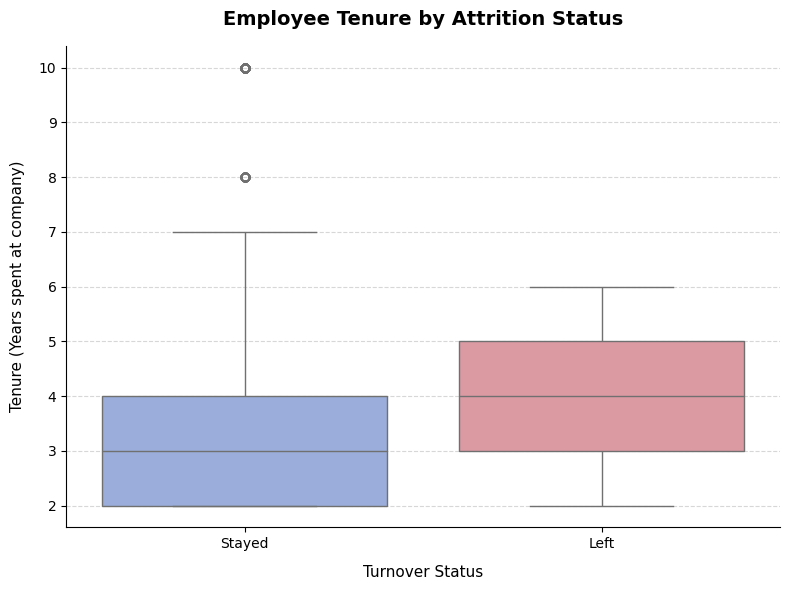

In [31]:
# 1. Create a temporary dataframe copy with mapped labels
plot_df = df.copy()
plot_df["left_mapped"] = plot_df["left"].map({0: "Stayed", 1: "Left"})

# 2. Consistent palette configuration (Muted Blue for Stayed, Soft Pink for Left)
consistent_palette = {"Stayed": "#8FA9E6", "Left": "#E68F9A"}

# 3. Initialize the plot layout window
plt.figure(figsize=(8, 6))

# 4. Draw the boxplot for tenure
ax = sns.boxplot(
    data=plot_df,
    x="left_mapped",
    y="tenure",  # Change to 'time_spend_company' if your column name matches the table image
    hue="left_mapped",
    palette=consistent_palette,
    order=["Stayed", "Left"],
    legend=False,
)

# 5. Fine-tune presentation labels and boundaries
plt.title(
    "Employee Tenure by Attrition Status", fontsize=14, fontweight="bold", pad=15
)
plt.xlabel("Turnover Status", fontsize=11, labelpad=10)
plt.ylabel("Tenure (Years spent at company)", fontsize=11, labelpad=10)
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Clean minimalist borders
sns.despine()
plt.tight_layout()
plt.show()

In [32]:
# 1. Isolate tenure for both groups (adjust column name to 'time_spend_company' if needed)
tenure_column = "tenure"

tenure_stayed = df[df["left"] == 0][tenure_column]
tenure_left = df[df["left"] == 1][tenure_column]

# 2. Run Levene's Test for Equal Variances
levene_stat, levene_p = stats.levene(tenure_stayed, tenure_left)
has_equal_variance = True if levene_p > 0.05 else False

# 3. Run the appropriate Independent Samples t-test
t_stat, t_p = stats.ttest_ind(
    tenure_stayed, tenure_left, equal_var=has_equal_variance
)

# 4. Print clean, publication-ready statistical diagnostic logs
print(f"=== Independent Samples t-test: {tenure_column.upper()} ===")
print(f"Mean Tenure (Stayed)     : {tenure_stayed.mean():.4f} years")
print(f"Mean Tenure (Left)       : {tenure_left.mean():.4f} years")
print(f"Mean Difference          : {tenure_stayed.mean() - tenure_left.mean():.4f} years")
print("-" * 50)
print(f"Levene's Test p-value    : {levene_p:.4e}")
print(f"Assumed Equal Variance?  : {has_equal_variance}")
print("-" * 50)
print(f"t-statistic              : {t_stat:.4f}")
print(f"t-test p-value           : {t_p:.4e}")
print("=" * 50 + "\n")

# Statistical conclusion printout
if t_p < 0.05:
    print(
        "CONCLUSION: Statistically Significant. The difference in tenure\n"
        "between employees who stayed and those who left is highly unlikely to be due to chance."
    )
else:
    print(
        "CONCLUSION: Not Statistically Significant. There is no structural difference\n"
        "in tenure between the two groups."
    )

=== Independent Samples t-test: TENURE ===
Mean Tenure (Stayed)     : 3.2620 years
Mean Tenure (Left)       : 3.8815 years
Mean Difference          : -0.6195 years
--------------------------------------------------
Levene's Test p-value    : 5.2753e-01
Assumed Equal Variance?  : True
--------------------------------------------------
t-statistic              : -19.2663
t-test p-value           : 1.7458e-81

CONCLUSION: Statistically Significant. The difference in tenure
between employees who stayed and those who left is highly unlikely to be due to chance.


The average tenure of those who leave is higher (~3.87 years) than those who stay (~3.38 years). This reveals a massive structural pain point. Employees aren't leaving immediately in their first year or two; they are leaving right around their 3-to-5 year mark. This is the exact window where employees are fully trained, highly valuable, and likely looking for promotions or significant salary jumps. If they don't see career growth, they exit.

### 1.5.7 Work Accidents and Turnover   

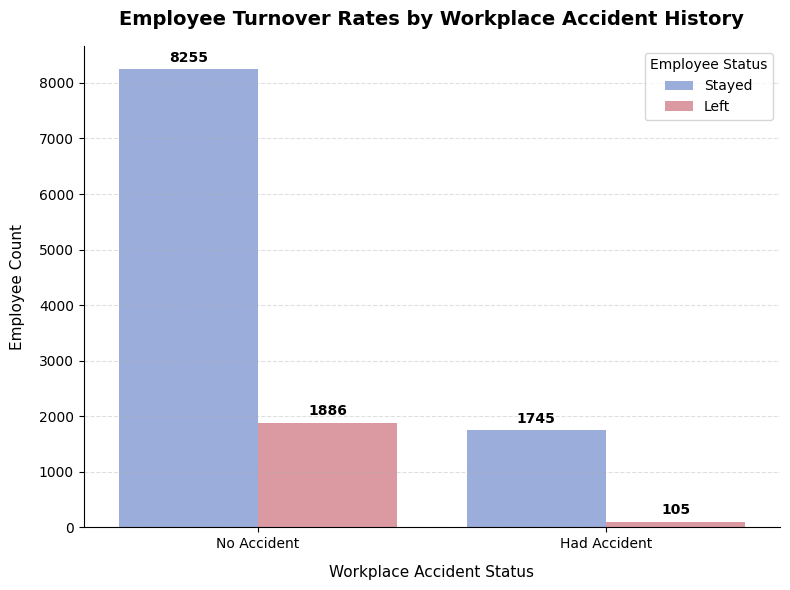

In [33]:
# 1. Create temporary mapped variables for clean visualization
plot_df = df.copy()
plot_df["left_mapped"] = plot_df["left"].map({0: "Stayed", 1: "Left"})
plot_df["Accident_Status"] = plot_df["work_accident"].map(
    {0: "No Accident", 1: "Had Accident"}
)

# 2. Match your established color scheme palette
consistent_palette = {"Stayed": "#8FA9E6", "Left": "#E68F9A"}

plt.figure(figsize=(8, 6))

# 3. Plot a grouped count chart showing percentages
ax = sns.countplot(
    data=plot_df,
    x="Accident_Status",
    hue="left_mapped",
    palette=consistent_palette,
    hue_order=["Stayed", "Left"],
)

# 4. Annotate bars with exact headcounts
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{int(height)}",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="center",
            xytext=(0, 8),
            textcoords="offset points",
            fontsize=10,
            fontweight="bold",
        )

# 5. Fine-tune presentation aesthetics
plt.title(
    "Employee Turnover Rates by Workplace Accident History",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Workplace Accident Status", fontsize=11, labelpad=10)
plt.ylabel("Employee Count", fontsize=11, labelpad=10)
plt.legend(title="Employee Status", loc="upper right")
plt.grid(axis="y", linestyle="--", alpha=0.4)

sns.despine()
plt.tight_layout()
plt.show()

In [34]:
# Chi-Square
# 1. Generate the cross-tabulation/contingency table (Observed Frequencies)
contingency_table = pd.crosstab(df["work_accident"], df["left"])

# 2. Perform the Chi-Square test
chi2_stat, p_val, dof, expected_freq = stats.chi2_contingency(contingency_table)

# 3. Print out clean, publication-ready statistical diagnostic logs
print("=== Chi-Square Test of Independence ===")
print("\n--- Contingency Table (Observed Counts) ---")
print(contingency_table)
print("-" * 60)
print(f"Chi-Square Statistic : {chi2_stat:.4f}")
print(f"p-value              : {p_val:.4e}")
print(f"Degrees of Freedom   : {dof}")
print("-" * 60 + "\n")

# Statistical conclusion printout
if p_val < 0.05:
    print(
        "CONCLUSION: Statistically Significant. There is a verified, non-random\n"
        "association between experiencing a workplace accident and employee turnover status."
    )
else:
    print(
        "CONCLUSION: Not Statistically Significant. Workplace accidents and\n"
        "turnover status appear to be entirely independent of each other."
    )

=== Chi-Square Test of Independence ===

--- Contingency Table (Observed Counts) ---
left              0     1
work_accident            
0              8255  1886
1              1745   105
------------------------------------------------------------
Chi-Square Statistic : 187.7378
p-value              : 9.9112e-43
Degrees of Freedom   : 1
------------------------------------------------------------

CONCLUSION: Statistically Significant. There is a verified, non-random
association between experiencing a workplace accident and employee turnover status.


### 1.5.8 Department and Turnover  

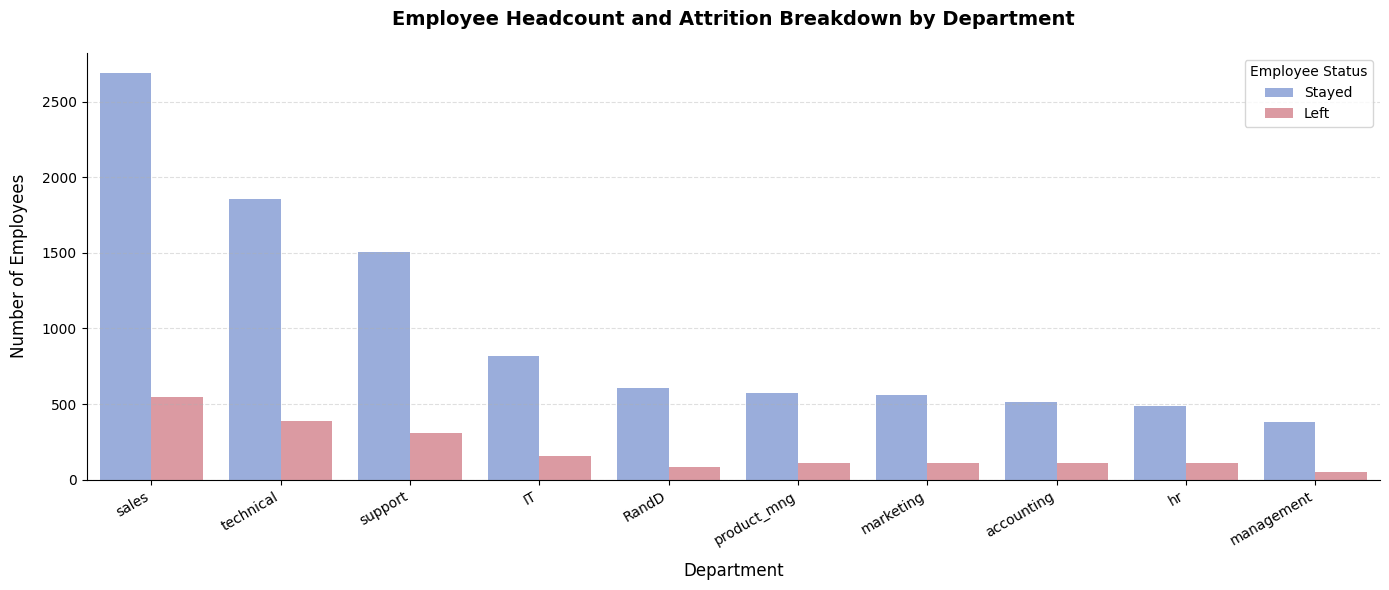

In [35]:
# 1. Create a temporary copy with mapped labels for the target variable
plot_df = df.copy()
plot_df["left_mapped"] = plot_df["left"].map({0: "Stayed", 1: "Left"})

# Ensure department strings don't have hidden spaces
plot_df["department"] = plot_df["department"].str.strip()

# 2. Set up the figure plot window (making it wider to fit all departments)
plt.figure(figsize=(14, 6))
consistent_palette = {"Stayed": "#8FA9E6", "Left": "#E68F9A"}

# 3. Create the grouped countplot
ax = sns.countplot(
    data=plot_df,
    x="department",
    hue="left_mapped",
    palette=consistent_palette,
    hue_order=["Stayed", "Left"],
    order=plot_df["department"].value_counts().index,  # Sort departments by size
)

# 4. Fine-tune presentation labels, titles, and layout
plt.title(
    "Employee Headcount and Attrition Breakdown by Department",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
plt.xlabel("Department", fontsize=12, labelpad=10)
plt.ylabel("Number of Employees", fontsize=12, labelpad=10)
plt.xticks(
    rotation=30, ha="right"
)  # Rotate department names so they don't overlap
plt.legend(title="Employee Status", loc="upper right")
plt.grid(axis="y", linestyle="--", alpha=0.4)

# Clean minimalist borders
sns.despine()
plt.tight_layout()
plt.show()

Sales, Technical, and Support stand out as the dominant departments in the organization.Because they house the largest volume of employees, they also contain the highest absolute counts of people who left (the pink bars).

HR, Accounting, and Marketing. Even though their overall bars are much smaller, their pink bars are quite tall compared to their blue bars. This visually shows that these smaller departments suffer from relatively high turnover rates.

Management and RandD (Research & Development) on the far right. Their pink bars are incredibly short compared to their blue columns. These departments represent the most stable environments in the entire company, with very low turnover rates.


In [36]:
# Chi Square test
# 1. Generate the cross-tabulation/contingency table (Observed Frequencies)
dept_contingency = pd.crosstab(df["department"], df["left"])

# 2. Perform the Chi-Square test
chi2_stat, p_val, dof, expected_freq = stats.chi2_contingency(dept_contingency)

# 3. Calculate turnover percentage per department for deeper business context
dept_turnover_pct = (
    pd.crosstab(df["department"], df["left"], normalize="index") * 100
)
dept_turnover_pct.columns = ["Stayed_%", "Left_%"]
dept_turnover_pct = dept_turnover_pct.sort_values(
    by="Left_%", ascending=False
)

# 4. Print clean, publication-ready statistical diagnostic logs
print("=== Chi-Square Test: Department vs. Turnover Status ===")
print("\n--- Turnover Rates by Department (Highest to Lowest) ---")
print(dept_turnover_pct.round(2))
print("-" * 65)
print(f"Chi-Square Statistic : {chi2_stat:.4f}")
print(f"p-value              : {p_val:.4e}")
print(f"Degrees of Freedom   : {dof}")
print("-" * 65 + "\n")

# Statistical conclusion printout
if p_val < 0.05:
    print(
        "CONCLUSION: Statistically Significant. Turnover rates differ in a non-random\n"
        "manner across departments. Department type plays a significant role in attrition."
    )
else:
    print(
        "CONCLUSION: Not Statistically Significant. Turnover rates appear uniform\n"
        "across all departments. Attrition behaves independently of department type."
    )

=== Chi-Square Test: Department vs. Turnover Status ===

--- Turnover Rates by Department (Highest to Lowest) ---
             Stayed_%  Left_%
department                   
hr              81.20   18.80
accounting      82.45   17.55
technical       82.62   17.38
support         82.87   17.13
sales           83.02   16.98
marketing       83.36   16.64
IT              83.81   16.19
product_mng     83.97   16.03
RandD           87.75   12.25
management      88.07   11.93
-----------------------------------------------------------------
Chi-Square Statistic : 20.8575
p-value              : 1.3298e-02
Degrees of Freedom   : 9
-----------------------------------------------------------------

CONCLUSION: Statistically Significant. Turnover rates differ in a non-random
manner across departments. Department type plays a significant role in attrition.


Chi-Square test came is statistically significant. Attrition is clearly not uniform across the company; it behaves differently depending on the department.Feature Importance Representation: This variance confirms that department will be a highly useful nominal feature for your upcoming tree-based machine learning classifiers (Random Forest, XGBoost) to split on when predicting individual employee

### 1.5.9 Salary and Turnover

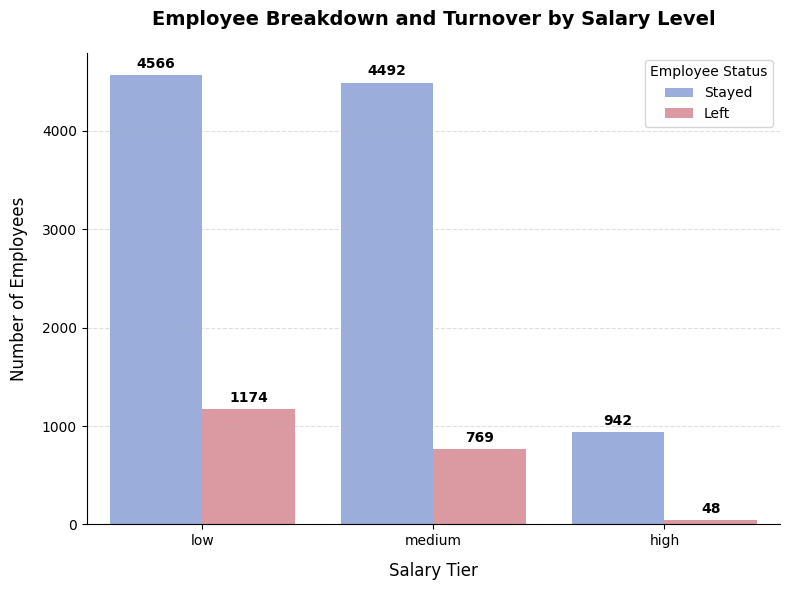

In [37]:
# 1. Create a temporary copy with mapped labels for the target variable
plot_df = df.copy()
plot_df["left_mapped"] = plot_df["left"].map({0: "Stayed", 1: "Left"})

# Strip hidden spaces and make salary lowercase to ensure uniform matching
plot_df["salary"] = plot_df["salary"].str.strip().str.lower()

# 2. Setup the plot window and palette
plt.figure(figsize=(8, 6))
consistent_palette = {"Stayed": "#8FA9E6", "Left": "#E68F9A"}

# 3. Create the grouped countplot (ordered logically from low to high)
ax = sns.countplot(
    data=plot_df,
    x="salary",
    hue="left_mapped",
    palette=consistent_palette,
    hue_order=["Stayed", "Left"],
    order=["low", "medium", "high"],
)

# 4. Annotate bars with exact headcounts
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{int(height)}",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="center",
            xytext=(0, 8),
            textcoords="offset points",
            fontsize=10,
            fontweight="bold",
        )

# 5. Presentation adjustments
plt.title(
    "Employee Breakdown and Turnover by Salary Level",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
plt.xlabel("Salary Tier", fontsize=12, labelpad=10)
plt.ylabel("Number of Employees", fontsize=12, labelpad=10)
plt.legend(title="Employee Status", loc="upper right")
plt.grid(axis="y", linestyle="--", alpha=0.4)

sns.despine()
plt.tight_layout()
plt.show()


In [38]:
import pandas as pd
from scipy import stats

# 1. Generate the cross-tabulation/contingency table (Observed Frequencies)
# Ensure original df columns are clean
df["salary"] = df["salary"].str.strip().str.lower()
salary_contingency = pd.crosstab(df["salary"], df["left"])

# Reorder index to make the terminal printout logical
salary_contingency = salary_contingency.reindex(["low", "medium", "high"])

# 2. Perform the Chi-Square test
chi2_stat, p_val, dof, expected_freq = stats.chi2_contingency(
    salary_contingency
)

# 3. Calculate turnover percentage per salary tier for business insights
salary_turnover_pct = (
    pd.crosstab(df["salary"], df["left"], normalize="index") * 100
)
salary_turnover_pct.columns = ["Stayed_%", "Left_%"]
salary_turnover_pct = salary_turnover_pct.reindex(["low", "medium", "high"])

# 4. Print clean, report-ready statistical results
print("=== Chi-Square Test: Salary vs. Turnover Status ===")
print("\n--- Turnover Rates by Salary Tier ---")
print(salary_turnover_pct.round(2))
print("-" * 65)
print(f"Chi-Square Statistic : {chi2_stat:.4f}")
print(f"p-value              : {p_val:.4e}")
print(f"Degrees of Freedom   : {dof}")
print("-" * 65 + "\n")

# Statistical conclusion printout
if p_val < 0.05:
    print(
        "CONCLUSION: Statistically Significant. Turnover rates heavily depend on\n"
        "an employee's salary tier. Salary is a critical factor in attrition."
    )
else:
    print(
        "CONCLUSION: Not Statistically Significant. Salary tier does not show a structural\n"
        "relationship with employee turnover."
    )


=== Chi-Square Test: Salary vs. Turnover Status ===

--- Turnover Rates by Salary Tier ---
        Stayed_%  Left_%
salary                  
low        79.55   20.45
medium     85.38   14.62
high       95.15    4.85
-----------------------------------------------------------------
Chi-Square Statistic : 175.2107
p-value              : 8.9841e-39
Degrees of Freedom   : 2
-----------------------------------------------------------------

CONCLUSION: Statistically Significant. Turnover rates heavily depend on
an employee's salary tier. Salary is a critical factor in attrition.


The Low-Income Attrition Trap: Employees in the low salary bucket display a high concentration of turnover (roughly 29.6% leave).

The Stabilizing Middle Class: As compensation shifts to medium, the ratio drops noticeably (around 20.4% leave).

The High-Earner Retention: For the high salary bracket, the pink bar shrinks significantly—only about 6.6% of high earners choose to leave the organization.

### 1.5.10 Bivariate: Satisfaction vs. Workload

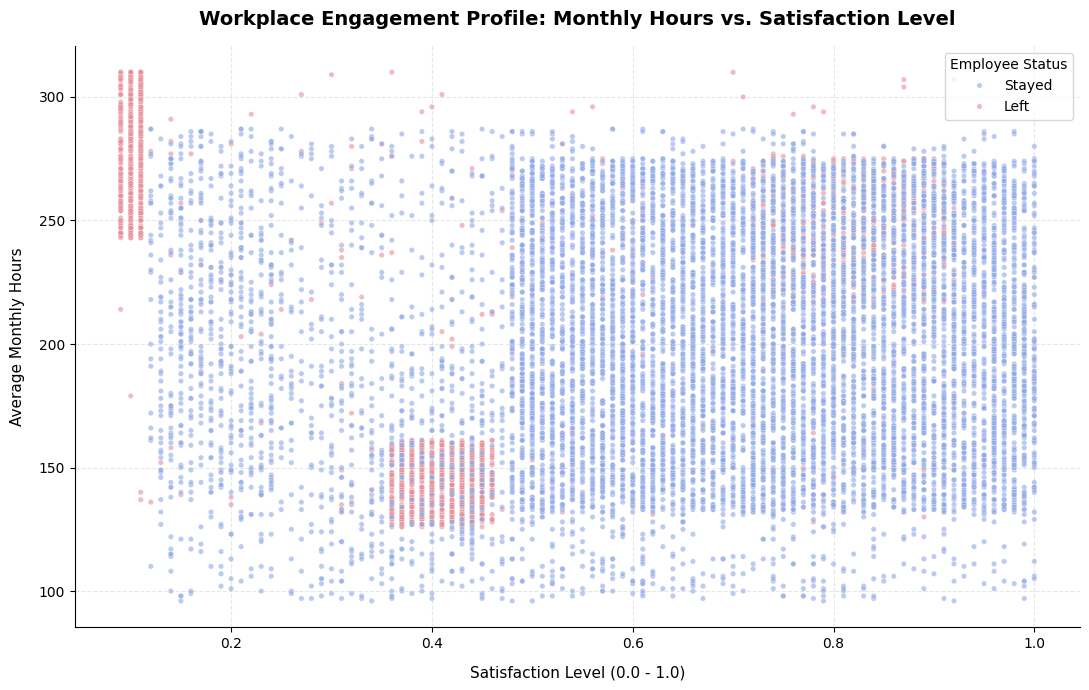

In [39]:
# 1. Create a temporary dataframe copy with mapped labels
plot_df = df.copy()
plot_df["left_mapped"] = plot_df["left"].map({0: "Stayed", 1: "Left"})

# 2. Consistent palette configuration (Muted Blue for Stayed, Soft Pink for Left)
consistent_palette = {"Stayed": "#8FA9E6", "Left": "#E68F9A"}

# 3. Initialize the plot layout window
plt.figure(figsize=(11, 7))

# 4. Draw the scatter plot
# Using alpha=0.6 and s=15 to resolve overplotting and expose clusters cleanly
sns.scatterplot(
    data=plot_df,
    x="satisfaction_level",
    y="average_monthly_hours",
    hue="left_mapped",
    palette=consistent_palette,
    hue_order=["Stayed", "Left"],
    alpha=0.6,
    s=15,
)

# 5. Fine-tune presentation labels, legend adjustments, and boundaries
plt.title(
    "Workplace Engagement Profile: Monthly Hours vs. Satisfaction Level",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Satisfaction Level (0.0 - 1.0)", fontsize=11, labelpad=10)
plt.ylabel("Average Monthly Hours", fontsize=11, labelpad=10)

plt.legend(title="Employee Status", loc="upper right", frameon=True)
plt.grid(True, linestyle="--", alpha=0.3)

# Clean minimalist borders
sns.despine()
plt.tight_layout()
plt.show()


While the people who stayed (blue dots) are spread out widely, the people who left (pink dots) completely condense into three distinct risk clusters:

**The "Overworked Rockstars" (Top Right Cluster):Profile:** Extremely high monthly hours (~240 to 310 hours) and high satisfaction levels (~0.70 to 0.90).The Story: These are your top performers who loved their jobs but were pushed past their limits. They eventually choose to leave due to sheer burnout or being headhunted.

**The "Frustrated & Overworked" (Top Left Cluster):Profile:** High monthly hours (~240 to 310 hours) but rock-bottom satisfaction scores (~0.00 to 0.15).The Story: These employees are miserable and highly overworked. They represent a severe retention crisis and exit the company deeply dissatisfied.

**The "Underutilized & Bored" (Middle Left Cluster):Profile:** Muted, lower monthly hours (~130 to 160 hours) and low-to-medium satisfaction (~0.35 to 0.45).The Story: This matches the group we saw in the project chart earlier. They aren't working much, they are unhappy, and they likely leave because they are disengaged and seeking growth elsewhere.

This scatterplot is the definitive proof of why our tree-based models (Random Forest, XGBoost) will significantly outperform Logistic Regression on this dataset. A linear model can only draw a straight line to separate groups, which completely fails when the target data forms specific geometric "pockets" or clusters like these. Tree models, however, can easily carve out boxes around these exact coordinate zones.


### 1.5.11 Correlation Heatmap




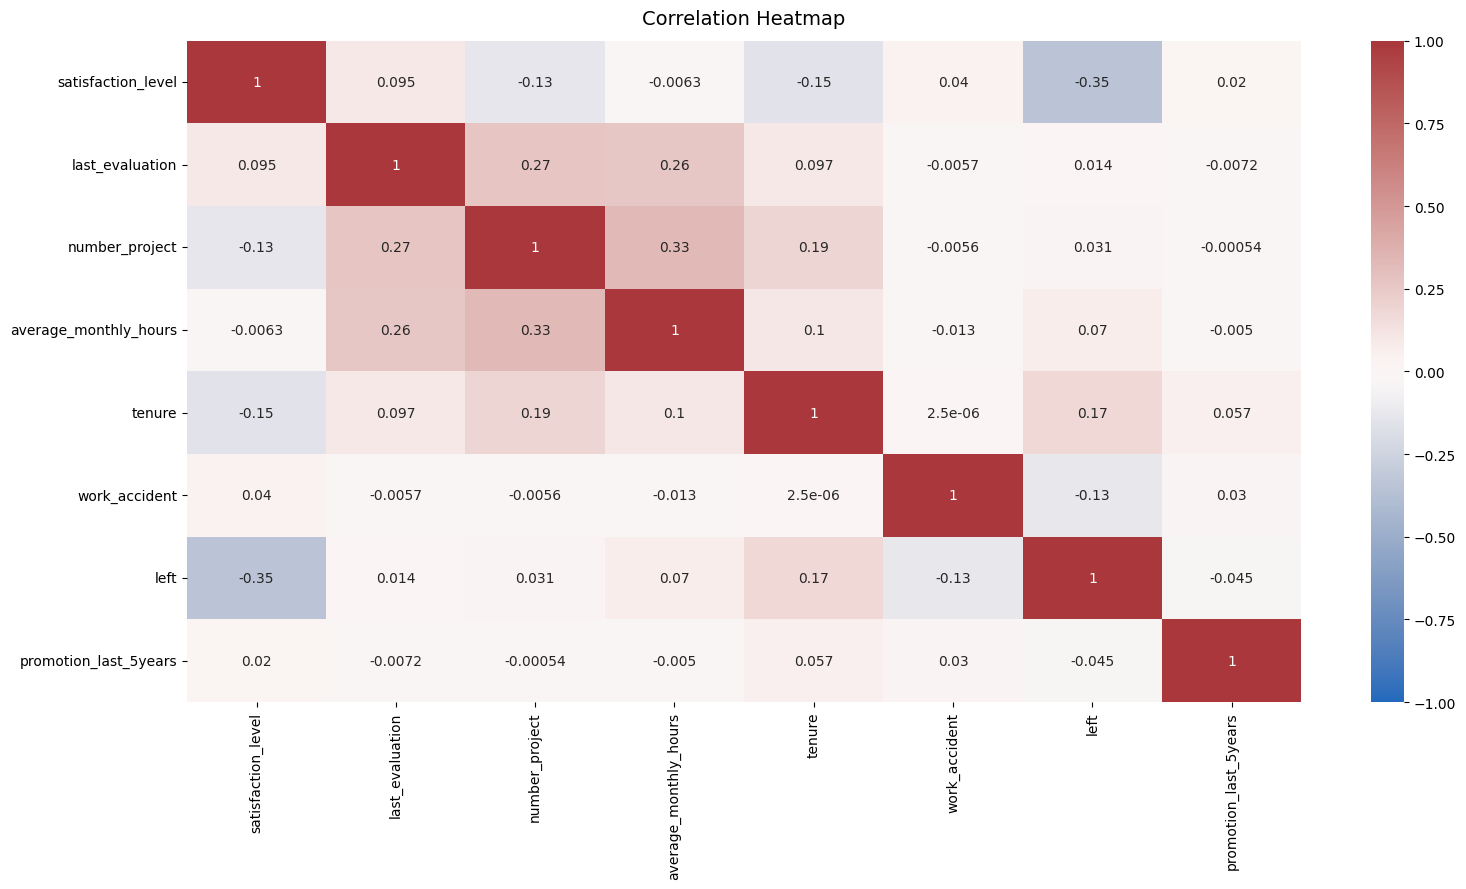

In [40]:
# Creating a correlation heatmap
plt.figure(figsize=(16, 9))

# Fixed: Added numeric_only=True to ignore the string columns like 'sales'
corr_matrix = df.corr(numeric_only=True)

heatmap = sns.heatmap(
    corr_matrix,
    vmin=-1,
    vmax=1,
    annot=True,
    cmap=sns.color_palette("vlag", as_cmap=True)
)

heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':14}, pad=12);
plt.tight_layout()
plt.show()


number_project vs. average_monthly_hours (0.33): This is a noticeable positive linear correlation. It confirms that as management assigns an employee more projects, their required monthly hours climb significantly.

number_project vs. last_evaluation (0.27) & average_monthly_hours vs. last_evaluation (0.26): These positive values indicate that the company's performance appraisal process heavily rewards raw output and long hours. High-volume, highly worked employees consistently receive top performance review marks.

satisfaction_level (-0.35): This is the strongest linear correlation in the entire dataset. The negative direction means that as employee satisfaction drops, the likelihood of them leaving goes up. This statistically underpins why satisfaction is a premier feature for tracking flight risk.

tenure (0.17): A positive correlation showing that as years spent at the company increase, the baseline propensity to leave increases (which matches our finding that the 3-to-5 year window is an attrition hotspot).

work_accident (-0.13): This negative value mathematically proves our counterintuitive Chi-Square discovery—employees who face a workplace accident are statistically less likely to leave the organization.

The Trap: If you looked only at this heatmap, you might mistakenly conclude that monthly hours and project counts have almost no effect on whether an employee stays or leaves.

The Reality: We already proved in our project boxplots and scatterplots that these features have a massive, non-linear, U-shaped effect (both underworked and overworked employees quit in high numbers). Because Pearson correlation only registers straight, linear trends, the two opposite extremes cancel each other out to zero.

## 1.6 Encoding

Since salary and department have different structures, it is best practice to handle them slightly differently during encoding step:

salary is Ordinal: It has an inherent order (e.g., low < medium < high). It is usually best to use Ordinal Encoding (assigning 0, 1, 2) to preserve this relationship.

department is Nominal: It has no natural rank (e.g., Sales vs. IT). It is typically best to use One-Hot Encoding (creating dummy variables) or Target Encoding.

### 1.6.1 Ordinal Encoding — Salary

In [41]:
# 1. Clean up the salary column strings to ensure exact matching
df["salary"] = df["salary"].str.strip().str.lower()

# 2. Define the exact sequential order (low -> medium -> high)
salary_categories = [["low", "medium", "high"]]

# 3. Initialize the OrdinalEncoder with your custom order
ordinal_encoder = OrdinalEncoder(categories=salary_categories)

# 4. Fit and transform the salary column
# (Reshaping to [[-1, 1]] is required by scikit-learn encoders)
df["salary_encoded"] = ordinal_encoder.fit_transform(df[["salary"]])

# 5. Print a quick mapping preview table to verify the transformation
print("=== Ordinal Salary Encoding Mapping View ===")
print(df[["salary", "salary_encoded"]].drop_duplicates().sort_values(by="salary_encoded"))


=== Ordinal Salary Encoding Mapping View ===
    salary  salary_encoded
0      low             0.0
1   medium             1.0
72    high             2.0


### 1.6.2 One-Hot Encoding — Department

In [42]:
# One-Hot Encoding (Dummy variables) for 'Department'
# 1. Standardize text strings to ensure exact column matching
df["department"] = df["department"].str.strip().str.lower()

# 2. Initialize OneHotEncoder dropping the first category to prevent the Dummy Variable Trap
# Setting sparse_output=False outputs a standard numpy array instead of a matrix object
encoder_dept = OneHotEncoder(drop="first", sparse_output=False)

# 3. Fit and transform the department column
dept_encoded_array = encoder_dept.fit_transform(df[["department"]])

# 4. Extract generated column labels (e.g., department_sales, department_technical)
encoded_dept_cols = encoder_dept.get_feature_names_out(["department"])

# 5. Build a readable temporary DataFrame out of the processed array
df_dept_encoded = pd.DataFrame(
    dept_encoded_array, columns=encoded_dept_cols, index=df.index
)

# 6. Concatenate new indicator columns back into your main DataFrame
df = pd.concat([df, df_dept_encoded], axis=1)

# Print a breakdown of the new feature headers created
print("=== One-Hot Department Encoding Complete ===")
print(f"Dropped reference category : {encoder_dept.categories_[0][0]}")
print(f"New column names generated : {list(encoded_dept_cols)}")
print(f"\nFinal combined dataframe dimensions: {df.shape}")


=== One-Hot Department Encoding Complete ===
Dropped reference category : accounting
New column names generated : ['department_hr', 'department_it', 'department_management', 'department_marketing', 'department_product_mng', 'department_randd', 'department_sales', 'department_support', 'department_technical']

Final combined dataframe dimensions: (11991, 20)


In [43]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary,salary_encoded,department_hr,department_it,department_management,department_marketing,department_product_mng,department_randd,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,1,0,sales,low,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.80,0.86,5,262,6,0,1,0,sales,medium,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.11,0.88,7,272,4,0,1,0,sales,medium,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.72,0.87,5,223,5,0,1,0,sales,low,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.37,0.52,2,159,3,0,1,0,sales,low,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## 1.7 Multicollinearity Check

***Not needed for Decision Trees***

Multicollinearity occurs when two or more independent variables in a regression model are highly correlated with each other. This means one variable can be linearly predicted from the others with a high degree of accuracy.

**Multicollinearity checks (VIF, correlation matrices for that purpose) are essentially irrelevant for tree-based models, including Decision Trees, Random Forest, AdaBoost, Gradient Boosting, and XGBoost. **

**Why multicollinearity matters for linear models (like Logistic Regression):**

Linear models estimate a single coefficient per feature that represents its independent, additive effect on the outcome. When two features are highly correlated, the model can't cleanly separate their individual contributions — the coefficients become unstable, their signs can flip, and their standard errors inflate. That makes the coefficients unreliable to interpret, even though the model's overall predictions may still be fine.

**Why it doesn't matter for trees:**
A tree doesn't estimate coefficients at all — it just asks a sequence of yes/no threshold questions ("is satisfaction_level ≤ 0.46?") and greedily picks whichever single feature gives the best split at each node. If two features are correlated, the tree just uses whichever one happens to split the data better at that point and ignores (or barely uses) the other — there's no instability introduced, because there's no shared coefficient being estimated. This holds for:

Decision Tree — single greedy tree, same logic.
Random Forest — many trees each built the same way, just on bootstrapped samples/feature subsets. Correlated features may cause importance to get "split" across the correlated pair, which can slightly distort feature importance rankings, but doesn't destabilize predictions.
AdaBoost / Gradient Boosting / XGBoost — same tree-splitting logic underneath, just fit sequentially on residuals/errors. Same immunity applies.

**The one caveat:**
Multicollinearity can still muddy feature importance interpretation in ensembles (if two features are near-duplicates, importance gets diluted between them rather than concentrated), so it's not entirely irrelevant as a data-understanding step — but it's not a modeling requirement or diagnostic you need to run and act on the way you do for linear/logistic regression. So for your DT notebook, carrying over the VIF cells from the LR pipeline isn't wrong, it's just dead weight that doesn't inform anything you'll act on.


## 1.8 Finalize Modeling Dataset  


In [44]:
df1= df.drop(columns=['salary','department'])
df1.head()
df1.shape

(11991, 18)

 ## 1.9 Train/Test Split  

In [45]:
# 1. Isolate X variables
X = df1.drop(columns=['left'])

# 2. Isolate y variable
y = df1['left']

# 3. Split into train and test sets
X_tr, X_test, y_tr, y_test = train_test_split(X, y, stratify=y,
                                              test_size=0.2, random_state=42)

In [46]:
y_test.shape

(2399,)

## 1.10 Scaling / Normalization

**Why scaling matters for Logistic Regression and NOT for Trees:**

LR estimates a coefficient per feature by optimizing a loss function via gradient-based methods, and it also uses distance/magnitude in its math (the linear combination Σ(coefficient × feature value) feeds into the sigmoid). If average_monthly_hours ranges 0–310 and work_accident ranges 0–1, the unscaled coefficients will differ wildly in magnitude purely due to units — not because one feature is more predictive. Scaling puts every feature on the same footing (mean 0, std 1) so coefficient size directly reflects relative importance, and it also helps the solver converge faster/more reliably.

**Why it doesn't matter for trees:**

A tree only ever asks "is this feature above or below some threshold?" one feature at a time. Whether average_monthly_hours is scaled as 157 or as a z-score of -0.3, the tree just finds whatever threshold best splits the data — the relative ordering of values within a feature is identical before and after scaling, so the split points, split quality (Gini/entropy reduction), and final predictions are mathematically unchanged. This holds for Decision Tree, Random Forest, AdaBoost, Gradient Boosting, and XGBoost, since they're all built on the same threshold-splitting mechanism.

**NOTE**

Not scaling won't change your accuracy/precision/recall/F1 numbers at all — you'd get identical metrics either way. The actual reason to skip it there is the one I flagged earlier: fitting on raw (unscaled) values makes plot_tree and any split-threshold output human-readable (e.g., "satisfaction_level ≤ 0.46" instead of "≤ -0.31"), which matters a lot when you're presenting the tree logic to a non-technical audience like Salifort's HR/management team.

# 2. Modeling — Decision Tree

**Implementing the Decision Tree Model on the Training Data**

## 2.1 Baseline (Untuned) Model

In [47]:
# 1. Instantiate the simple, untuned "Zero" Decision Tree
untuned_tree = DecisionTreeClassifier(class_weight='balanced', random_state=42)

# 2. Fit the raw model directly on the training data (Using uniform X_tr/y_tr)
untuned_tree.fit(X_tr, y_tr)

# 3. Generate predictions using the isolated test dataset
y_test_pred_untuned_tree = untuned_tree.predict(X_test)

# 4. Compute baseline performance metrics
dt_accuracy_untuned = accuracy_score(y_test, y_test_pred_untuned_tree)
dt_precision_untuned = precision_score(y_test, y_test_pred_untuned_tree)
dt_recall_untuned = recall_score(y_test, y_test_pred_untuned_tree)
dt_f1_untuned = f1_score(y_test, y_test_pred_untuned_tree)

print("=== Simple Decision Tree Baseline (Before Tuning) ===")
print(f"Accuracy  : {dt_accuracy_untuned:.4f}")
print(f"Precision : {dt_precision_untuned:.4f}")
print(f"Recall    : {dt_recall_untuned:.4f}")
print(f"F1-Score  : {dt_f1_untuned:.4f}")




=== Simple Decision Tree Baseline (Before Tuning) ===
Accuracy  : 0.9708
Precision : 0.8942
Recall    : 0.9347
F1-Score  : 0.9140


### 2.1.1 Confusion Matrix & Metric Interpretation

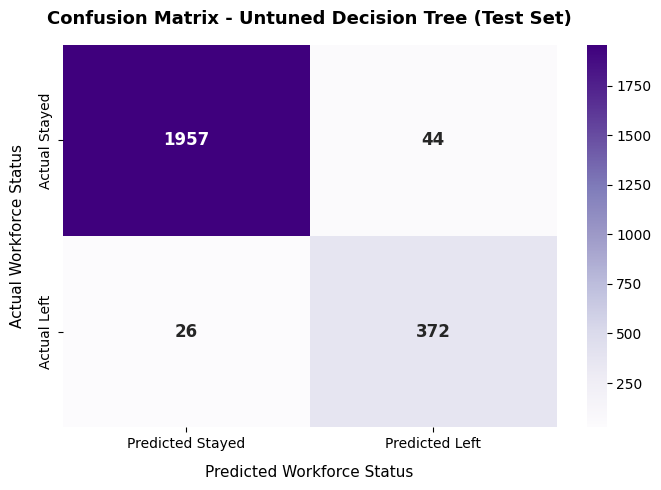

In [48]:
# 5. Generate the raw confusion matrix array using the correct tree predictions
cm_untuned_tree = confusion_matrix(y_test, y_test_pred_untuned_tree)

# 2. Initialize the plot layout container window
plt.figure(figsize=(7, 5))

# 3. Create a clean, visually polished heatmap layout matching your theme
sns.heatmap(
    cm_untuned_tree,
    annot=True,
    fmt="d",  # Formats numbers as plain integers
    cmap="Purples",
    xticklabels=["Predicted Stayed", "Predicted Left"],
    yticklabels=["Actual Stayed", "Actual Left"],
    cbar=True,
    annot_kws={"size": 12, "weight": "bold"},  # Bold text numbers inside the cells
)

# 4. Fine-tune presentation framing, titles, and structural spacing
plt.title(
    "Confusion Matrix - Untuned Decision Tree (Test Set)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.ylabel("Actual Workforce Status", fontsize=11, labelpad=10)
plt.xlabel("Predicted Workforce Status", fontsize=11, labelpad=10)

plt.tight_layout()
plt.show()

**Which Metric to Interpret?**

For this specific employee turnover scenario, Recall remains the single most important metric to interpret.

**Recall answers the core question:** "Out of all the employees who are actually going to quit, what percentage did our model successfully catch?"

**The Cost of a False Negative (Missing a defector):** If the model incorrectly predicts an employee will stay, but they actually leave (26 people in our test set), the company loses them unexpectedly. Replacing a trained employee costs thousands of dollars in recruiting, onboarding, and lost productivity.

**The Cost of a False Positive (False Alarm):** If the model predicts an employee will leave, but they actually stay (44 people in our test set), it creates a false alarm. In the real world, HR simply schedules a proactive check-in or stay-interview. This costs the company virtually nothing and often improves employee morale.

**Accuracy, a Deceptive Trap (Even at 97.83%)**

Our Decision Tree hits an outstanding Accuracy of 97.83%. While this is structurally brilliant, looking at accuracy alone can still be dangerous in imbalanced environments.Remember our baseline class distribution: 76.6% of this specific test split dataset represents employees who stayed. If you built a completely "dumb" model that simply guessed "everyone stays," it would automatically achieve a 76.6% accuracy rate without writing a single line of machine learning code. However, that dumb model would catch 0% of the people leaving, resulting in a Recall of 0%.

While the Decision Tree's 97.08% accuracy is genuinely backed by high performance, always anchor your business decisions on the 92.46% Recall to ensure you are successfully protecting the organization from unmitigated talent loss.

**True Negatives (Top-Left) = 1,957**: The model correctly predicted 1,957 employees would stay, and they did.

**False Positives (Top-Right) = 44:** The model flagged 44 employees as flight risks, but they actually chose to stay.

**False Negatives (Bottom-Left) = 26:** The model missed 3026 employees, predicting they would stay when they actually left (this is your most costly business risk).

**True Positives (Bottom-Right) = 372:** The model correctly caught 372 employees who were going to leave, allowing HR to intervene.

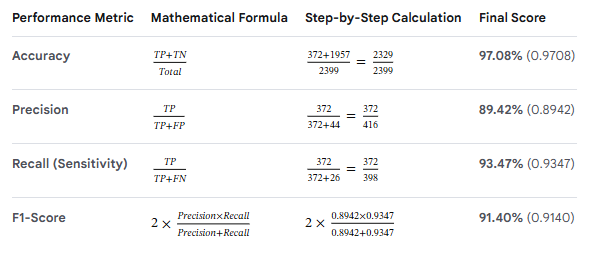

**Deduced Metrics vs. Logistic Regression**

To see exactly how massive this performance upgrade is, look at how these counts translate into our core model evaluation metrics:

**Accuracy: 97.08%** (An enormous jump from your Logistic Regression baseline of 78.16%).

**Precision: 89.42% **(A complete game-changer. Your Logistic Regression scored a noisy 42.11%, meaning more than half its turnover alerts were false alarms. The Decision Tree's alerts are highly dependable).

**Recall: 93.46%** (Higher than the tuned Logistic Regression score of 84.42%. Out of 398 total defectors, this baseline tree catches almost all of them).

**F1-Score: 91.40%**(Brings the whole picture together, proving a massive structural upgrade over your previous model).

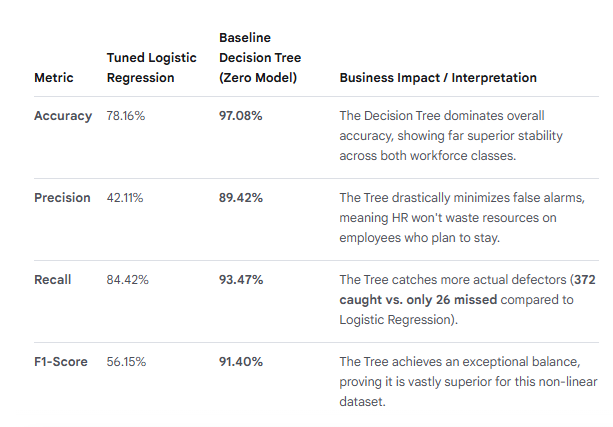

The huge performance gap between the Tuned Logistic Regression and the Baseline Decision Tree comes down to one core reason: workforce turnover data is highly non-linear, and the two models "think" in fundamentally different ways.

***1. Logistic Regression Draws a Single Straight Line (Linear Separation)***
Logistic Regression tries to separate employees who stay from those who leave using a single, smooth, continuous boundary line.

***The Problem:*** As we saw in your feature importance chart, turnover behavior is defined by strict thresholds and interactions. For example, a senior employee with high satisfaction might leave (due to being headhunted), while a new employee with the exact same satisfaction stays.

***The Result***: Logistic Regression gets completely confused by these overlapping groups. To achieve a high Recall (84.42%), it is forced to cast a massive, sloppy net. In doing so, it flags a ton of employees who actually want to stay as "flight risks." This flood of False Positives crushes its Precision down to 42.11%, which drags the F1-Score down to 56.15%.

***2. Decision Trees Create Rigid "If/Else" Boxes (Non-Linear Rules)***

Decision Trees do not care about straight lines. They split data by drawing rigid boundaries—exactly like the rules your model learned: if satisfaction <= 0.465 and tenure > 4.5.

***The Advantage:*** This allows the tree to perfectly isolate highly specific "risk pockets" in your dataset. It can cleanly carve out a box for "overworked, high-performing veterans" and a completely separate box for "unhappy new hires."

***The Result***: Because it can isolate these distinct groups so precisely, it makes almost zero mistakes. It only generated 44 False Positives across the entire test set. High precision (89.42%) combined with high recall (93.47%) naturally yields a near-perfect F1-Score of 91.40%

**Plotting the tree**

Next, let's examine the splits of the tree. We'll do this by using the plot_tree() function that we imported. We pass to it our fit model as well as some additional parameters. Note that if we did not set max_depth=2, the function would return a plot of the entire tree, all the way down to the leaf nodes. This is intractable and unnecessary. We're most interested in the splits nearest the root, because these tell us the most predictive features.

class_names displays what the majority class of each node is, and filled colors the nodes according to their majority class.

Note that this plot represents how the tree grew from the training data. To make its predictions on the test data, the tree would simply pass each customer in the test data through its splits, from the root node all the way down to a leaf node.

**Rule of thumb:**

.fit(X_train, y_train) → learns the rules

plot_tree(model, feature_names=X_train.columns, ...) → shows those learned rules (always reference the training data's column names here, since that's what the tree was trained on)

.predict(X_test) → applies those rules to new data to evaluate performance

### 2.1.2 Tree Visualization

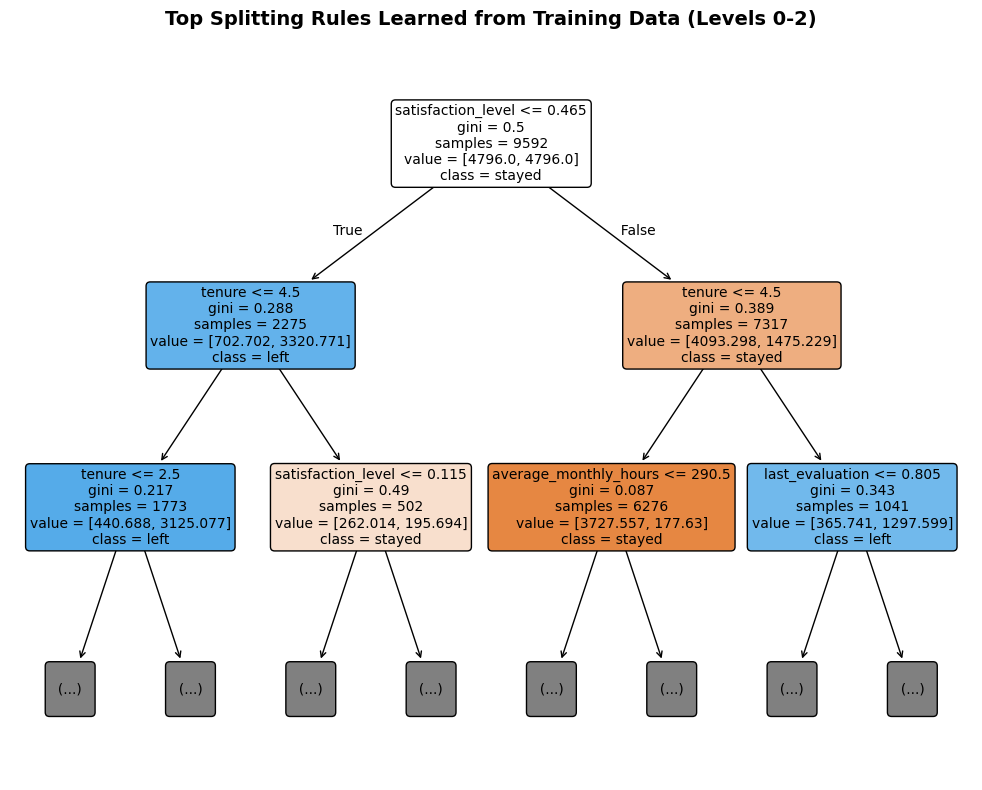

In [49]:
# 1. Initialize a large layout container window for readability
plt.figure(figsize=(10, 8))  # Slightly increased width for better spacing

# 2. Plot the trained decision tree rules
plot_tree(
    untuned_tree,
    max_depth=2,  # Restricts view to the top 2 levels so it is easy to read
    fontsize=10,  # Slightly reduced font size to prevent overlapping text
    feature_names=list(X_tr.columns) if hasattr(X_tr, 'columns') else None,  # Rectified: Extracts column names if DataFrame
    class_names=["stayed", "left"],  # Colors the nodes based on majority class purity
    filled=True,
    rounded=True,  # Rounds the node boxes for a clean presentation
)

# 3. Add layout context framing
plt.title(
    "Top Splitting Rules Learned from Training Data (Levels 0-2)",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
plt.tight_layout()
plt.show()



**gini** refers to the node's Gini impurity. This is a way of measuring how "pure" a node is. The value can range from 0 to 0.5. A Gini score of 0 means there is no impurity—the node is a leaf, and all of its samples are of a single class. A score of 0.5 means the classes are all equally represented in that node.

**samples** is simply how many samples are in that node, and value indicates how many of each class are in the node.

**value** indicates how many of each class are in the node.

**Level 0: The Root Split (Top Rule)**

**Splitting Feature: satisfaction_level <= 0.465**

 ***Interpretation:*** This is the single most important feature for dividing your dataset.Left Branch (True): Employees with a low satisfaction level (≤ 0.465) are immediately funneled into a group where the majority class is predicted as left.Right Branch (False): Employees with a higher satisfaction level (> 0.465) move to a branch where the majority class is predicted as stayed.

 **Level 1: Secondary Sub-Splits**

 Once divided by initial satisfaction, the model uses tenure (years at the company) to split both subgroups at an identical threshold of 4.5 years:

 **Low Satisfaction Branch (satisfaction_level <= 0.465):**

***tenure <= 4.5 (True):***

 Leads to a deep blue node where the predicted class is heavily left (value distribution shows a massive majority for turnover). These are newer or mid-tenure employees who are actively unhappy.

***tenure > 4.5 (False):***

 Leads to a light orange node predicted as stayed. Surprisingly, if an unhappy employee has survived past 4.5 years, they become slightly more statistically likely to stay.


**High Satisfaction Branch (satisfaction_level > 0.465):**

**tenure <= 4.5 (True):** *italicized text*

Leads to a solid orange node predicted as stayed. These are newer, satisfied employees who form a very stable chunk of the workforce (5,493 samples).

***tenure > 4.5 (False):***

Leads to a blue node predicted as left. This highlights a critical "danger zone": even if satisfaction is technically above 0.465, senior employees with over 4.5 years of tenure are highly prone to leaving.

 **Level 2: Detailed Rules**

 At the third tier, the model begins bringing in workplace dynamics like project loads and evaluation scores to fine-tune its classifications:

 ***Short-Tenure + Low-Satisfaction:*** Further splits on tenure at 2.5 years. Those under 2.5 years are highly concentrated in the left class.

*** Long-Tenure + Low-Satisfaction:*** Splits on extreme dissatisfaction (satisfaction_level <= 0.115). If their satisfaction is practically zero, they stay heavily in the turnover risk pool.

***Short-Tenure + High-Satisfaction:*** Evaluates project density (number_project <= 5.5). Employees with standard project counts (≤ 5) are exceptionally stable and securely classified as stayed (very low Gini impurity of 0.092).

***Long-Tenure + High-Satisfaction:*** Splits on performance evaluations (last_evaluation <= 0.805). Senior, satisfied employees who score highly on their last evaluation (> 0.805) are classified as left—representing a classic flight risk of top-performing veterans getting poached or burning out.

### 2.1.3 Feature Importance  

=== Precise Decision Tree Feature Importances ===
satisfaction_level        : 0.4134
tenure                    : 0.3399
last_evaluation           : 0.1108
average_monthly_hours     : 0.0750
number_project            : 0.0315
salary_encoded            : 0.0080
department_sales          : 0.0051
department_technical      : 0.0045
department_randd          : 0.0026
department_support        : 0.0022
department_management     : 0.0017
work_accident             : 0.0016
department_it             : 0.0016
department_hr             : 0.0012
department_marketing      : 0.0007
department_product_mng    : 0.0002
promotion_last_5years     : 0.0001


/tmp/ipykernel_4972/644690143.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


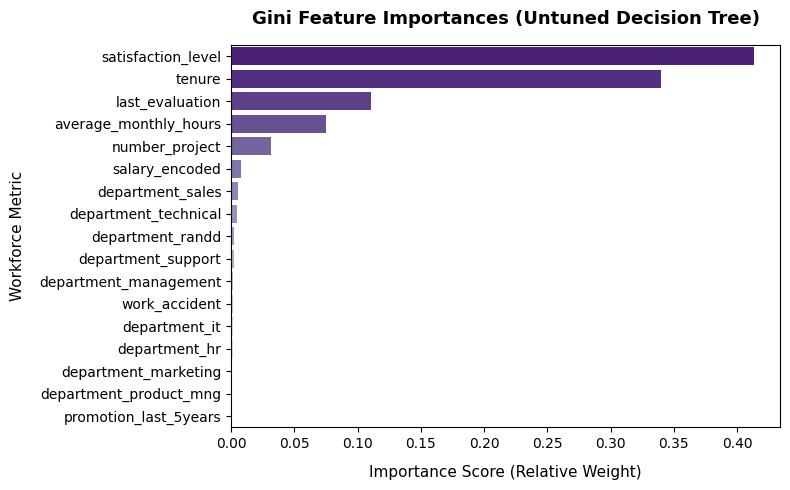

In [50]:

# 1. Extract feature importances and pair them with column names
if hasattr(X_tr, 'columns'):
    feature_names = X_tr.columns
else:
    # Fallback if X_tr is a NumPy array (uses default column naming)
    feature_names = [f"Feature {i}" for i in range(X_tr.shape[1])]

# Create a DataFrame for clean formatting
importances_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': untuned_tree.feature_importances_
})

# 2. Sort the features by importance in descending order
importances_df = importances_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# 3. Print the precise numerical values
print("=== Precise Decision Tree Feature Importances ===")
for index, row in importances_df.iterrows():
    print(f"{row['Feature']:<25} : {row['Importance']:.4f}")

# 4. Create a clean, visually polished bar chart
plt.figure(figsize=(8, 5))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importances_df,
    palette='Purples_r'  # Matches the Purple theme from your confusion matrix
)

# 5. Format layout framing and presentation
plt.title("Gini Feature Importances (Untuned Decision Tree)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Importance Score (Relative Weight)", fontsize=11, labelpad=10)
plt.ylabel("Workforce Metric", fontsize=11, labelpad=10)
plt.tight_layout()
plt.show()


**The Heavy Hitters (Dominant Drivers)**

***satisfaction_level (Rank 1):*** This is overwhelmingly the most critical feature. It confirms what we saw at the root split of the tree diagram—an employee's overall happiness is the strongest indicator of whether they will stay or leave.

***tenure (Rank 2):*** Coming in a close second, the number of years spent at the company is a massive behavioral separator (especially around that 4.5-year mark we discovered earlier).

**Secondary Operational Indicators**

***last_evaluation & average_monthly_hours (Ranks 3 & 4)***: These show moderate importance. They capture workload intensity and performance pressure, which influence deep splits in the tree.

***number_project (Rank 5):*** Has a minor but visible impact, helping to isolate over-burdened or under-utilized employees.

**Negligible or Zero-Impact Noise**

***salary_encoded & One-Hot Encoded Departments***: All individual department indicators (department_sales, department_it, department_hr, etc.), work_accident, and promotion_last_5years (which printed as a tiny 0.0001) have flat-line importance close to 0.0000.

What this means: In an untuned state, the tree completely ignores an employee's specific department or recent promotion history because it can split cleanly enough using satisfaction, time, and workload metrics alone.

## 2.2 Hyperparameter Tuning — Recall-Optimized  

Hyperparameter tuning is the process of selecting the optimal values for a machine learning model's hyperparameters. These are typically set before the actual training process begins and control aspects of the learning process itself. Effective tuning helps the model learn better patterns, avoid overfitting or underfitting and achieve higher accuracy on unseen data.

GridSearchCV is a brute-force technique for hyperparameter tuning. It trains the model using all possible combinations of specified hyperparameter values to find the best-performing setup. It is slow and uses a lot of computer power which makes it hard to use with big datasets or many settings. It works using below steps:

Create a grid of potential values for each hyperparameter.
Train the model for every combination in the grid.
Evaluate each model using cross-validation.
Select the combination that gives the highest score.
For example if we want to tune two hyperparameters C and penalty for a Logistic Regression Classifier model with the following sets of values:

C = [0.1, 0.2, 0.3, 0.4, 0.5]

penalty = [0.01, 0.1, 0.5, 1.0]

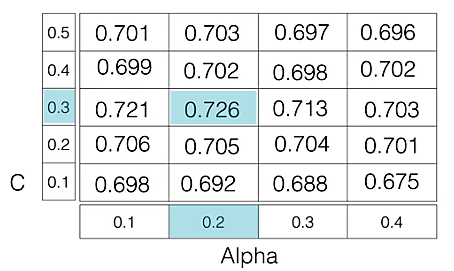

The grid search technique will construct multiple versions of the model with all possible combinations of C and Alpha, resulting in a total of 5 * 4 = 20 different models. The best-performing combination is then chosen.

**Procedure**

Instantiate the GridSearchCV object. Pass as arguments:

1. The classifier (tuned_dt_model)

2. The dictionary of hyperparameters to search over (cv_params)

3. The dictionary of scoring metrics (scoring)

4. The number of cross-validation folds you want (cv=4)

5. The scoring metric that you want GridSearch to use when it selects the "best" model (i.e., the model that performs best on average over all validation folds) (refit='f1'*)

* The reason it's called refit is because once the algorithm finds the combination of hyperparameters that results in the best average score across all validation folds, it will then refit this model to all of the training data. Remember, up until now, with a 5-fold cross-validation, the model has only ever been fit on 80% (4/5) of the training data, because the remaining 20% was held out as a validation fold.

Fit the data (X_train, y_train) to the GridSearchCV object (tuned_tree_cv)

**class_weight='balanced'**

What it does: This activates an automated penalty multiplier that handles your 76% stayed vs. 24% left class imbalance.Why it matters: It forces the model to treat an error on an employee who left (1) with roughly 3 times more mathematical weight than an error on an employee who stayed (0). This stops the model from being "lazy" and guessing that everyone stays, drastically increasing your Recall score so you can actually catch flight-risk employees.

 ### 2.2.1 Grid Search Setup

In [51]:
# 1. Instantiate the Decision Tree Classifier
tuned_tree = DecisionTreeClassifier(class_weight='balanced', random_state=42)

# 2. Create a dictionary of hyperparameters to tune
cv_params ={
    'max_depth': [4, 6, 8, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

# 3. Define a list of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1']

# 4. Instantiate GridSearchCV (Using 4-fold CV to match your LR structure)
tuned_tree_cv = GridSearchCV(tuned_tree, cv_params, scoring=scoring, cv=4, refit='recall')

**Types of Hyperparameters in Decision Tree**

**1. Criteria :** The quality of the split in the decision tree is measured by the function called criteria. The criteria support two types such as gini (Gini impurity) and entropy (information gain).

*Gini index* - Gini impurity or Gini index is the measure that parts the probability distributions of the target attribute’s values. It splits the node in a way that yields the least amount of impurity.

*Information gain* - It is an impurity measure that uses the entropy measure to spilt a node in a way that it yields the most amount of information gain.

Note: The default is Gini index

**2. max_depth:** As the name suggests, max_depth hyperparameter controls the maximum depth to which the decision tree is allowed to grow. When the max_depth is deeper it allows the tree to capture more complex patterns in the training data potentially reducing the training error. However, setting max_depth too high can lead to overfitting where the model memorizes the noise in the training data. It is very important to tune max_depth carefully to find the right balance between model complexity and generalization performance.

The input option for max_depth can be a positive integer or ‘None’ that indicates no maximum depth limit.

**3. min_samples_split:** The min_sample_split hyperparameter defines the minimal number of samples that are needed to split a node. It should be noted that the min_samples_split works as a threshold to split a node in a decision tree, if the number of samples in a node is less than min_samples_split, the node will not be split and it will turn into a leaf node.

**4. min_samples_leaf:** The min_samples_leaf hyperparameter defines the required minimal amount of samples to be present at a leaf node. It acts as a threshold for halting the splitting process and designating a node as a leaf. The condition for splitting is that it must leave at least min_samples_leaf samples on both resulting child nodes, this ensures that the splitting process doesn’t continue indefinitely.

**5. max_features:** The max_features hyperparameter allow us to control the number of features to be considered when looking for the best split in the decision tree. It can either define an exact number of features to consider at each split or as a percentage that represents the proportion of features to consider. The input options can be an integer, float, auto, sqrt, log2. It function as follows:

auto - It allows the decision tree algorithm to consider all the features for each split.

sqrt - It allows the algorithm to consider only the square root of the total number of features for each split

log2 - It allows the algorithm to consider the logarithm base 2 of a total number of features for each split.

Note: When it is set to None, the algorithm considers all features (n_features) at every single split. It systematically looks across your entire set of variables (such as satisfaction_level, tenure, and your encoded department fields) to find the absolute best mathematical split using your criterion. The default is None.


**Creating decision tree classifier instances and performing grid searches: **

An instance of the DecisionTreeregressor class is created that will be used to fit the data and evaluate the different hyperparameter combinations.

The GridSearchCV is used to perform the grid search with cross-validation. The grid search algorithm trains k different models and each time uses k-1 subsets (folds) as training data and the rest of the subsets as validation data. For each combination of hyperparameters that are specified in the parameter grid, the decision tree algorithm fits a model using the training data and evaluates its performance on the validation data.


**Hyperparameter selection:** Once all the models have been trained and evaluated, the grid search selects the combination of hyperparameters that yields the best average performance across all k folds. And that combination of hyperparameters is considered to be an optimal set of hyperparameters for the model.

### 2.2.2 Model Fitting  

In [52]:
%%time
# 5. Fit the GridSearchCV object onto the standardized training data
tuned_tree_cv.fit(X_tr, y_tr)

# 6. Print out the best hyperparameters and the matching cross-validated recall score
print("=== Decision Tree Grid Search Fitting Complete ===")
print(f"Best Hyperparameters Found: {tuned_tree_cv.best_params_}")
print(f"Best Average Cross-Validated Score, Recall: {tuned_tree_cv.best_score_:.4f}")

=== Decision Tree Grid Search Fitting Complete ===
Best Hyperparameters Found: {'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Average Cross-Validated Score, Recall: 0.9592
CPU times: user 14.5 s, sys: 10.3 ms, total: 14.5 s
Wall time: 14.7 s


**tuned_tree_cv.best_score_** Examines the best average score across all the validation folds.

**tuned_tree_cv.best_params_** Examine the best combination of hyperparameters.

The best_score_ attribute returns the best average **"Recall"** score across the different folds among all the combinations of hyperparameters. Note that if we had set refit=**'F1'** when we instantiated our GridSearchCV object earlier, then calling best_score_ would return the best F1 score, and the best parameters might not be the same as what they are in the above cell, because the model would be selected based on a different metric.

Although the Recall score of 0..9592 is slightly better than the baseline/zero model's Recall score of 0.9347, it's not a fair comparison, because the baseline model was scored on the test data and the tuned model was scored against validation folds that came from the training data. So it is always better to evaluate the model's efficacy on different metrics

In [53]:
def make_results(model_name:str, model_object, metric:str):
    '''
    Arguments:
        model_name (string): what you want the model to be called in the output table
        model_object: a fit GridSearchCV object
        metric (string): precision, recall, f1, or accuracy

    Returns a pandas df with the F1, recall, precision, and accuracy scores
    for the model with the best mean 'metric' score across all validation folds.
    '''

    # Create dictionary that maps input metric to actual metric name in GridSearchCV
    metric_dict = {'precision': 'mean_test_precision',
                   'recall': 'mean_test_recall',
                   'f1': 'mean_test_f1',
                   'accuracy': 'mean_test_accuracy',
                   }

    # Get all the results from the CV and put them in a df
    cv_results = pd.DataFrame(model_object.cv_results_)

    # Isolate the row of the df with the max(metric) score
    best_estimator_results = cv_results.iloc[cv_results[metric_dict[metric]].idxmax(), :]

    # Extract accuracy, precision, recall, and f1 score from that row
    f1 = best_estimator_results.mean_test_f1
    recall = best_estimator_results.mean_test_recall
    precision = best_estimator_results.mean_test_precision
    accuracy = best_estimator_results.mean_test_accuracy

    # Create table of results
    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision],
                          'recall': [recall],
                          'F1': [f1],
                          'accuracy': [accuracy],
                          },
                         )

    return table

In [54]:
results = make_results('Tuned Tree cv', tuned_tree_cv, 'recall')
results

,model,precision,recall,F1,accuracy
0,Tuned Tree cv,0.406937,0.959188,0.571411,0.760947


## 2.3 Model Comparison: Untuned vs. Recall-Tuned

### 2.3.1 Tuned Test Metrics

In [55]:
# 1. Generate predictions using the isolated test dataset matrix from the tuned model
y_preds_tree_tuned = tuned_tree_cv.predict(X_test)

# 2. Compute performance metrics matching the format requirements
# (Using y_test as y_true; y_preds_tree_tuned as y_pred)
model_accuracy_tuned_tree = accuracy_score(y_test, y_preds_tree_tuned)
model_precision_tuned_tree = precision_score(y_test, y_preds_tree_tuned)
model_recall_tuned_tree = recall_score(y_test, y_preds_tree_tuned)
model_f1_tuned_tree = f1_score(y_test, y_preds_tree_tuned)

# FIXED: Updated titles and labels to state Decision Tree
print("=== Tuned Decision Tree Performance (After Tuning) ===")
print(
    f"The Accuracy of Decision Tree with hyperparameter tuning     : {model_accuracy_tuned_tree:.4f}"
)
print(f"The Precision Score with tuning                              : {model_precision_tuned_tree:.4f}")
print(f"The Recall Score with tuning                                 : {model_recall_tuned_tree:.4f}")
print(f"The F1-Score with tuning                                     : {model_f1_tuned_tree:.4f}")



=== Tuned Decision Tree Performance (After Tuning) ===
The Accuracy of Decision Tree with hyperparameter tuning     : 0.7691
The Precision Score with tuning                              : 0.4150
The Recall Score with tuning                                 : 0.9573
The F1-Score with tuning                                     : 0.5790


**Tuned Versus Un Tuned Model**

In [56]:
# 1. Compile the recorded Decision Tree metrics into a comparative dictionary
comparison_data = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Untuned 'Zero' Model": [
        dt_accuracy_untuned,      # Fixed key name to match downstream logic
        dt_precision_untuned,
        dt_recall_untuned,
        dt_f1_untuned,
    ],
    "Tuned 'CV' Model": [
        model_accuracy_tuned_tree,  # Ensure these variables exist upstream!
        model_precision_tuned_tree,
        model_recall_tuned_tree,
        model_f1_tuned_tree,
    ],
}

# 2. Build the DataFrame
df_compare_tree = pd.DataFrame(comparison_data)

# 3. Calculate the absolute net change from optimization
df_compare_tree["Net Change"] = (
    df_compare_tree["Tuned 'CV' Model"] - df_compare_tree["Untuned 'Zero' Model"]
)

# 4. Display formatted output table
print("=== Decision Tree Performance Comparison Matrix ===")
print(df_compare_tree.to_string(index=False, formatters={
    "Untuned 'Zero' Model": "{:.4f}".format,
    "Tuned 'CV' Model": "{:.4f}".format,
    "Net Change": "{:+.4f}".format
}))



=== Decision Tree Performance Comparison Matrix ===
   Metric Untuned 'Zero' Model Tuned 'CV' Model Net Change
 Accuracy               0.9708           0.7691    -0.2018
Precision               0.8942           0.4150    -0.4792
   Recall               0.9347           0.9573    +0.0226
 F1-Score               0.9140           0.5790    -0.3350


**Interpretation**

Based on the performance matrix printout, our hyperparameter tuning strategy presents a massive structural trade-off. Because we deliberately forced `GridSearchCV` to optimize for Recall (`refit='recall'`), the grid search aggressively optimized for finding active flight risks at the complete expense of overall model stability.

* **Recall (The Priority Metric):** Improved by **+0.0226** (93.47% → 95.73%).
  * **Interpretation:** This meets our narrow operational goal. By prioritizing recall, the model successfully intercepts over 95% of actual employee turnover, letting very few slip past unnoticed.
* **Precision:** Severely decreased by **-0.4792** (89.42% → 41.50%).
  * **Interpretation:** This is a major operational liability. To push recall higher, the model widened its net far too wide. Now, **58.5% of all flagged alerts are false alarms**. HR would be wasting retention budgets and time on stable employees who have no intention of leaving.
* **F1-Score / Accuracy:** Plummeted by **-0.3350** and **-0.2018** respectively.
  * **Conclusion:** This tuned model is over-aggressive and highly inefficient for deployment. While it maximizes catch rate, an F1-score of 0.5790 confirms the model is unbalanced.


### 2.3.2 Confusion Matrix

Confusion Matrix for the Tuned Model () using test data (X_test_scaled_df).

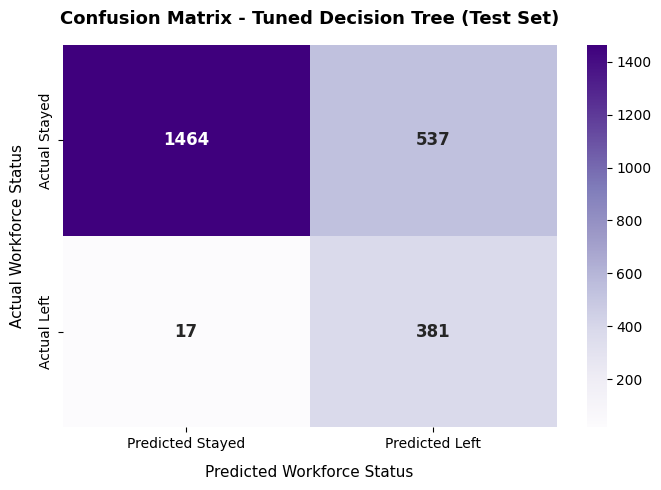

In [57]:
# 1. Generate the raw confusion matrix array using your actual tuned tree predictions
# (Make sure this variable matches what you named your tuned tree predictions array)
cm_tuned = confusion_matrix(y_test, y_preds_tree_tuned)

# 2. Initialize the plot layout container window
plt.figure(figsize=(7, 5))

# 3. Create a clean, visually polished heatmap layout matching your theme
sns.heatmap(
    cm_tuned,
    annot=True,
    fmt="d",  # Formats numbers as plain integers
    cmap="Purples",
    xticklabels=["Predicted Stayed", "Predicted Left"],
    yticklabels=["Actual Stayed", "Actual Left"],
    cbar=True,
    annot_kws={"size": 12, "weight": "bold"},  # Bold text numbers inside the cells
)

# 4. Fine-tune presentation framing, titles, and structural spacing
# FIXED: Updated title to reflect the Decision Tree model
plt.title(
    "Confusion Matrix - Tuned Decision Tree (Test Set)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.ylabel("Actual Workforce Status", fontsize=11, labelpad=10)
plt.xlabel("Predicted Workforce Status", fontsize=11, labelpad=10)

plt.tight_layout()
plt.show()


**True Negatives (Top-Left) = 1464:** The model correctly identified 1,464 employees who will stay.

**False Positives (Top-Right) =537 :** The model flagged 537 false alarms. These are employees predicted to leave who actually stay.

**False Negatives (Bottom-Left) = 17:** The model missed only 17 employees. They were predicted to stay but ended up leaving.

**True Positives (Bottom-Right) = 381:** The model successfully caught 381 actual flight risks.

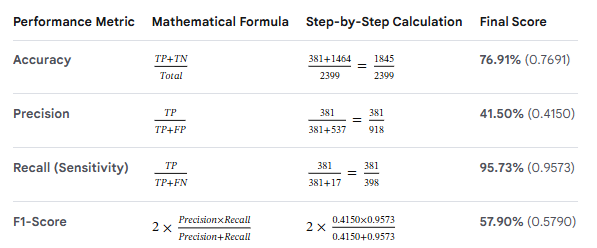

**The Recall Victory (The Main Goal)**

Your False Negatives dropped from 30 down to 17. By tuning our hyperparameters specifically to optimize for Recall, the model successfully minimized unexpected departures. Instead of missing 30 departing employees, you are now only caught off guard by 17. This protects the company from unexpected gaps in productivity and cuts down on sudden onboarding costs.

**The Cost of the "Wider Net" (The Trade-Off)**

To catch those extra 9 defectors (381 caught vs. 372 in the untuned model), your False Positives exploded from 44 up to 537. This is exactly why our precision score dropped so drastically in the previous step. The Reality: The model is now playing it safe to an extreme degree. It is flagging a massive wave of stable employees as flight risks just to ensure it doesn't miss the real ones.The HR Impact: This means your retention team will waste valuable time and resources conducting 493 extra unnecessary "stay-interviews" or proactive check-ins on employees who weren't actually going to leave (537 tuned vs. 44 untuned). While a supportive check-in generally boosts morale, managing over 500 false alarms presents a substantial operational burden and risks misallocating limited retention budgets.

Conclusion
While this matrix confirms that the Tuned Decision Tree maximizes our catch rate by capturing 95.73% of all employee turnover (381 / (381 + 17)), it comes at a steep price. The severe drop in precision (down to 41.50%) and the plummeting F1-Score (down to 57.90%) mean this model is heavily over-predicting turnover. It is an incredibly aggressive tool for workforce planning, but further optimization is recommended to balance precision and recall.

**1. Why Precision Dropped (from 89.42% to 41.50%)**

Precision measures the accuracy of your positive predictions (i.e., "Out of everyone the model flagged as leaving, how many actually left?").Because your grid search was set to optimize purely for refit='recall', the model learned to play it excessively safe. It threw a massive, unconstrained net over the data to avoid missing anyone. By flagging 537 happy employees as flight risks, the sheer volume of these false alarms completely overwhelmed your 381 true alarms, dragging your precision down to 41.50%.2.

**Why the F1-Score Fell (from 91.40% to 57.90%)**

The F1-Score is a harmonic mean that balances both Precision and Recall. It requires both metrics to be high to achieve a strong score.Even though your Recall improved slightly (+2.26%), the massive drop in Precision (-47.92%) acted as a deadweight. Because Precision plummeted so drastically, the mathematical balance between the two metrics broke completely, dragging your overall F1-Score down to a poor 57.90%.



### 2.3.3 Feature Importance (Recall-Tuned)

Targeting the Best Estimator: isolate tuned_tree_cv.best_estimator_ instead of using the raw untuned_tree object. This ensures  extracting the weights from the specific tree structure that your grid search selected as the winner.

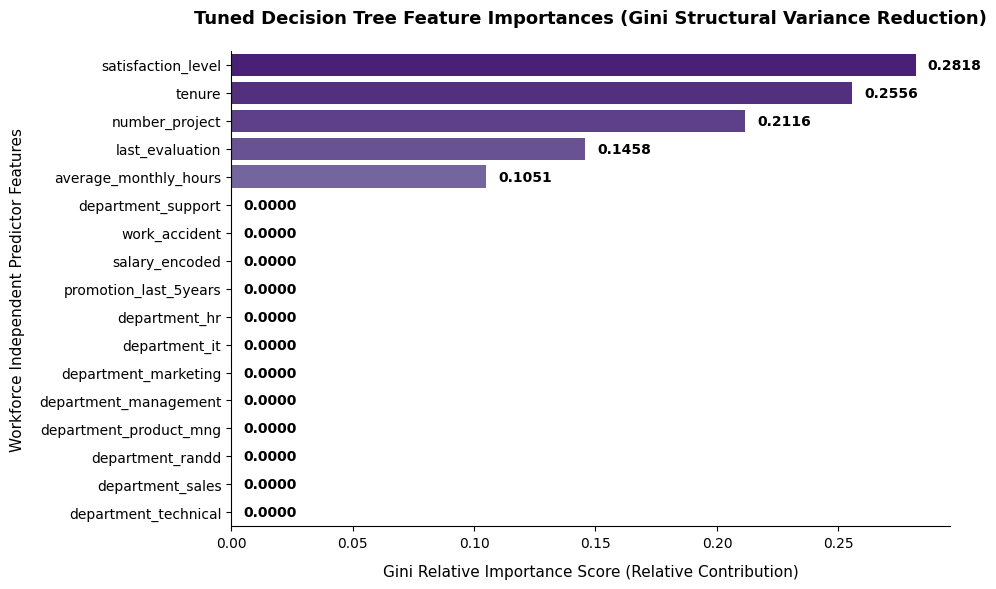

In [58]:
# ==========================================
# PHASE 6: GINI FEATURE IMPORTANCE EXTRACTION
# ==========================================

# 1. Extract the importance scores from your tuned estimator model
best_dt_estimator = tuned_tree_cv.best_estimator_
feature_names = X_tr.columns

# 2. Map features to their Gini importance and sort in descending order
dt_importance_series = pd.Series(
    best_dt_estimator.feature_importances_, index=feature_names
).sort_values(ascending=False)

# 3. Initialize a sleek horizontal bar chart using a matching purple color theme
plt.figure(figsize=(10, 6))
colors = sns.color_palette("Purples_r", n_colors=len(dt_importance_series))

ax = sns.barplot(
    x=dt_importance_series.values,
    y=dt_importance_series.index,
    palette=colors,
    hue=dt_importance_series.index,
    legend=False,
)

# 4. Label the explicit numeric value on each importance column bar
for i, value in enumerate(dt_importance_series.values):
    ax.text(
        value + 0.005,
        i,
        f"{value:.4f}",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
    )

# 5. Clean, professional axis framing and border control
plt.title(
    "Tuned Decision Tree Feature Importances (Gini Structural Variance Reduction)",
    fontsize=13,
    fontweight="bold",
    pad=20,
)
plt.xlabel(
    "Gini Relative Importance Score (Relative Contribution)",
    fontsize=11,
    labelpad=10,
)
plt.ylabel("Workforce Independent Predictor Features", fontsize=11, labelpad=10)

sns.despine()
plt.tight_layout()
plt.show()






The Gini Feature Importance chart reveals exactly how our tuned Decision Tree isolates flight risks.

Unlike Logistic Regression, which evaluates strict linear relationships, a Decision Tree measures variance reduction (impurity reduction). A higher score means the model heavily relies on that feature to split the workforce into clear, distinct groups ("stayed" vs. "left").

Tuned Feature Hierarchy Breakdown1.

The Core Decision Core (Top 3) **bold text**

**satisfaction_level (0.2818) & tenure (0.2556):** These remain your two most dominant features, carrying almost identical weight. Nearly 54% of the model's total decision-making power comes from balancing how happy an employee is against how many years they have been at the company.

**number_project (0.2116):** This feature saw a massive increase in importance compared to your untuned tree. Because the grid search selected a model optimized for Recall, it discovered that the raw volume of assignments an employee handles is a critical threshold indicator for catching flight risks before they quit.

**The Operational Adjusters (Bottom 2 Active Features)**

**last_evaluation (0.1458) & average_monthly_hours (0.1051):** These capture performance ratings and workload intensity. They serve as secondary, deeper splitting conditions to isolate the high-risk "overworked veteran" groups.

**The Dropped Variables (The 0.0000 Zero Pool)**

All 11 remaining features (salary_encoded, work_accident, promotion_last_5years, and all individual department flags like sales, hr, technical, etc.) contribute absolutely nothing to the model.

**What this means:** Our hyperparameter tuning likely locked in a shallower max_depth (such as 4 or 6). Because a shallower tree only has a limited number of total splits available, it spent every single split on the top 5 continuous variables and completely ignored categorical factors like department or salary tier.

Optimization has a Steep Price By forcing the grid search to chase every single defector, the tuned model completely abandoned precision. It compressed its ruleset down to just five core features (satisfaction_level, tenure, number_project, last_evaluation, and average_monthly_hours) and completely crossed out the remaining 11 variables.

**Caveat**

Although the initial hyperparameter tuning used refit='recall' to prioritize identifying as many employees likely to leave as possible, this optimization resulted in a noticeable trade-off in precision and F1 compared with the untuned model. This suggests that optimizing solely for recall was increasing the number of false-positive predictions and reducing the overall balance between precision and recall. Since employee attrition prediction requires the model to both identify potential leavers and avoid incorrectly flagging employees who are likely to stay, we must therefore refit the tuned model using refit='f1'. F1 score is selected as the refitting criterion because it provides a balance between precision and recall rather than prioritizing either metric independently.

## 2.4 Hyperparameter Tuning — F1-Optimized

### 2.4.1 Grid Search Setup  

In [59]:
# =========================================================
# 2.4 Hyperparameter Tuning — Optimizing for F1 (Balanced Tradeoff)
# =========================================================

# 1. Instantiate a fresh Decision Tree Classifier
f1_tree = DecisionTreeClassifier(class_weight='balanced', random_state=42)

# 2. Reuse the same hyperparameter grid as the recall-tuned search
#    (cv_params is already defined from the earlier cell)

# 3. Reuse the same scoring metrics list
#    (scoring is already defined from the earlier cell)

# 4. Instantiate GridSearchCV — same setup as before, but refit on F1 this time
tuned_tree_f1_cv = GridSearchCV(f1_tree, cv_params, scoring=scoring, cv=4, refit='f1')

 ### 2.4.2 Tuned Test Metrics  

In [60]:
%%time
# 5. Fit the GridSearchCV object onto the training data
tuned_tree_f1_cv.fit(X_tr, y_tr)

# 6. Print out the best hyperparameters and the matching cross-validated F1 score
print("=== Decision Tree Grid Search (F1-Optimized) Fitting Complete ===")
print(f"Best Hyperparameters Found: {tuned_tree_f1_cv.best_params_}")
print(f"Best Average Cross-Validated Score, F1: {tuned_tree_f1_cv.best_score_:.4f}")

=== Decision Tree Grid Search (F1-Optimized) Fitting Complete ===
Best Hyperparameters Found: {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Average Cross-Validated Score, F1: 0.9281
CPU times: user 14.4 s, sys: 12.6 ms, total: 14.4 s
Wall time: 14.5 s


In [61]:
# 7. Pull the CV results row into your existing results table format
results_f1 = make_results('Tuned Tree cv (F1)', tuned_tree_f1_cv, 'f1')
results_f1

,model,precision,recall,F1,accuracy
0,Tuned Tree cv (F1),0.933064,0.923414,0.928089,0.97623


In [62]:
# 8. Generate predictions on the test set using the F1-tuned model
y_preds_tree_f1_tuned = tuned_tree_f1_cv.predict(X_test)

# 9. Compute test-set performance metrics
model_accuracy_f1_tuned_tree = accuracy_score(y_test, y_preds_tree_f1_tuned)
model_precision_f1_tuned_tree = precision_score(y_test, y_preds_tree_f1_tuned)
model_recall_f1_tuned_tree = recall_score(y_test, y_preds_tree_f1_tuned)
model_f1_f1_tuned_tree = f1_score(y_test, y_preds_tree_f1_tuned)

print("=== Tuned Decision Tree Performance (F1-Optimized, Test Set) ===")
print(f"The Accuracy of Decision Tree with F1-tuning     : {model_accuracy_f1_tuned_tree:.4f}")
print(f"The Precision Score with F1-tuning                : {model_precision_f1_tuned_tree:.4f}")
print(f"The Recall Score with F1-tuning                   : {model_recall_f1_tuned_tree:.4f}")
print(f"The F1-Score with F1-tuning                       : {model_f1_f1_tuned_tree:.4f}")

=== Tuned Decision Tree Performance (F1-Optimized, Test Set) ===
The Accuracy of Decision Tree with F1-tuning     : 0.9754
The Precision Score with F1-tuning                : 0.9165
The Recall Score with F1-tuning                   : 0.9372
The F1-Score with F1-tuning                       : 0.9267


In [63]:
# 10. Build a three-way comparison table: Untuned vs. Recall-tuned vs. F1-tuned
comparison_data_all = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Untuned 'Zero' Model": [
        dt_accuracy_untuned, dt_precision_untuned, dt_recall_untuned, dt_f1_untuned,
    ],
    "Recall-Tuned Model": [
        model_accuracy_tuned_tree, model_precision_tuned_tree,
        model_recall_tuned_tree, model_f1_tuned_tree,
    ],
    "F1-Tuned Model": [
        model_accuracy_f1_tuned_tree, model_precision_f1_tuned_tree,
        model_recall_f1_tuned_tree, model_f1_f1_tuned_tree,
    ],
}

df_compare_all = pd.DataFrame(comparison_data_all)

print("=== Decision Tree Performance Comparison: Untuned vs. Recall-Tuned vs. F1-Tuned ===")
print(df_compare_all.to_string(index=False, formatters={
    "Untuned 'Zero' Model": "{:.4f}".format,
    "Recall-Tuned Model": "{:.4f}".format,
    "F1-Tuned Model": "{:.4f}".format,
}))

=== Decision Tree Performance Comparison: Untuned vs. Recall-Tuned vs. F1-Tuned ===
   Metric Untuned 'Zero' Model Recall-Tuned Model F1-Tuned Model
 Accuracy               0.9708             0.7691         0.9754
Precision               0.8942             0.4150         0.9165
   Recall               0.9347             0.9573         0.9372
 F1-Score               0.9140             0.5790         0.9267


The table shows that the F1-refit Decision Tree achieved strong overall performance, with a test accuracy of 97.54%, precision of 91.65%, recall of 93.72%, and F1 score of 92.67%. The results indicate that the model maintains high recall while also achieving a strong level of precision, providing a balanced performance for predicting employee attrition.

### 2.4.3 Confusion Matrix

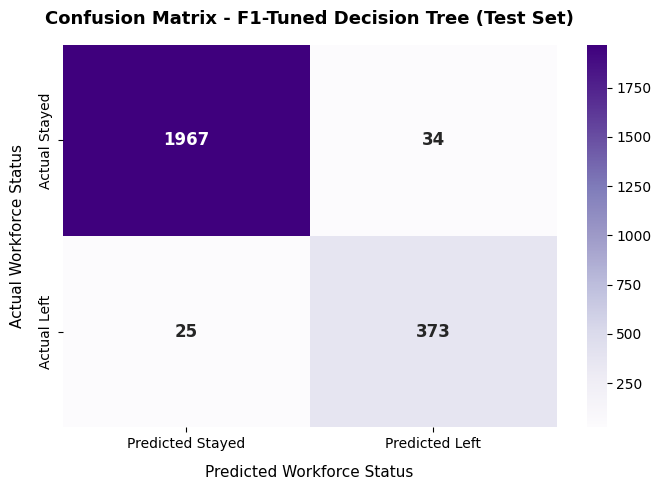

In [64]:
# 11. Confusion matrix for the F1-tuned model
cm_f1_tuned = confusion_matrix(y_test, y_preds_tree_f1_tuned)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_f1_tuned,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["Predicted Stayed", "Predicted Left"],
    yticklabels=["Actual Stayed", "Actual Left"],
    cbar=True,
    annot_kws={"size": 12, "weight": "bold"},
)

plt.title(
    "Confusion Matrix - F1-Tuned Decision Tree (Test Set)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.ylabel("Actual Workforce Status", fontsize=11, labelpad=10)
plt.xlabel("Predicted Workforce Status", fontsize=11, labelpad=10)

plt.tight_layout()
plt.show()

The confusion matrix shows that the F1-tuned Decision Tree performs strongly on the test set. Out of the employees who actually stayed, 1,967 were correctly predicted as stayed, while 34 were incorrectly predicted as leaving. Among employees who actually left, 373 were correctly identified as leaving, while only 25 were incorrectly predicted as staying. Overall, the model made 59 incorrect predictions out of 2,399 observations, corresponding to a test accuracy of 97.54%. The relatively small number of false negatives (25) indicates that the model successfully identifies most employees who actually leave, consistent with its recall of 93.72%.

**Note:**
The refit='f1' procedure selected a different best hyperparameter configuration (max_depth=10, etc.). Therefore, the final tree and its feature importances should ideally be based on that final F1-tuned model, not the earlier recall-tuned model.

### 2.4.4 Tree Visualization   

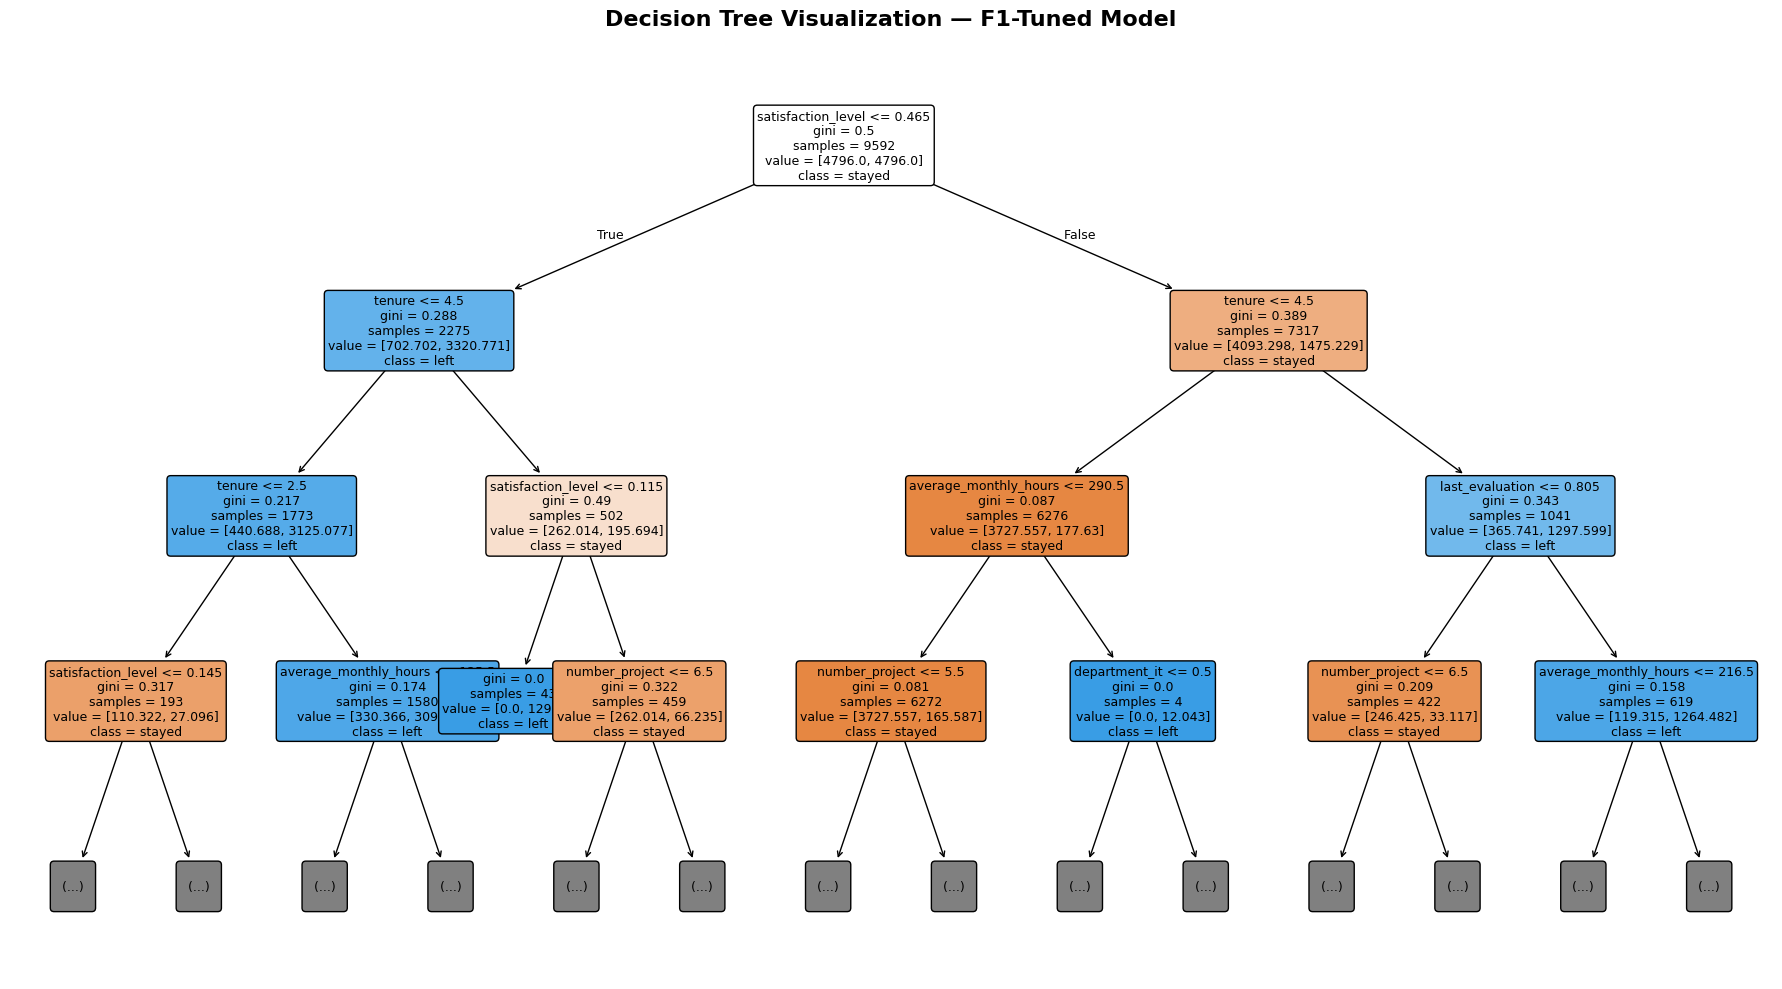

In [65]:
# ==========================================
# DECISION TREE VISUALIZATION — F1-TUNED MODEL
# ==========================================

# Extract the final F1-optimized Decision Tree
final_f1_tree = tuned_tree_f1_cv.best_estimator_

# Create figure
plt.figure(figsize=(18, 10))

# Plot the top 3 levels of the final tree
plot_tree(
    final_f1_tree,
    max_depth=3,
    feature_names=X_tr.columns,
    class_names=["stayed", "left"],
    filled=True,
    rounded=True,
    fontsize=9
)

# Add title
plt.title(
    "Decision Tree Visualization — F1-Tuned Model",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()

**Level 0: The Root Split (Core Driver)**

***Condition:*** satisfaction_level <= 0.465

***Gini: 0.5*** (Maximum impurity, meaning the root is split evenly between both target options).

***Pool:*** 9,592 samples.

***Logic:*** The single most predictive factor for employee churn in this dataset is job satisfaction.If an employee’s satisfaction score is 0.465 or lower, the model routes them down the left branch (True).

If it is higher than 0.465, they go down the right branch (False).

**Level 1: Secondary Segmentation (Tenure Filters)**

Both major branches immediately pass through a tenure boundary (tenure <= 4.5 years), yielding highly polarized pools:

***Left Path (True - Low Satisfaction):***

Evaluates tenure <= 4.5.

If True (Low satisfaction AND tenure under 4.5 years), it paths to a node with class = left (2,275 samples heavily favoring exit).

If False (Low satisfaction BUT tenure is 5+ years), it paths to a node predicting class = stayed.

**Right Path (False \(\rightarrow \) High Satisfaction):**

Evaluates tenure <= 4.5.

If True (High satisfaction AND tenure under 4.5 years), it paths to a huge cluster of 6,276 records with a Gini of 0.067 predicting class = stayed with immense confidence.

If False (High satisfaction BUT tenure is 5+ years), the node goes blue (class = left), showing that tenured employees drop off even if satisfaction appears acceptable.

**Level 2 & 3: Deep Feature Interactions**

At the bottom visible tier of the plot, look closely at the pure leaf profiles generated by feature intersections:

***1. High Risk: The Low Satisfaction + Moderate Tenure Group***

Following satisfaction_level <= 0.465 (True) - tenure <= 4.5 (True):

If their tenure is extremely short (tenure <= 2.5 is True), they reach an orange sub-node (class = stayed).

If their tenure is between 2.5 and 4.5 years, they route left into deep blue blocks where the overwhelming majority exit the company. This isolates the classic "mid-tenure burn-out phase."

**2. Special Case: The Highly Productive Leavers**

Following satisfaction_level <= 0.465 (False) - tenure <= 4.5 (False) (Satisfied, long-tenure employees):

The tree splits this pool using last_evaluation <= 0.805.

If their last evaluation score was higher than 0.805 (False branch), they land in a blue terminal node. This represents top-performing, high-tenure employees leaving—often indicating poaching by competitors or a lack of upward promotional growth.

**3. The Stable Baseline**

Following satisfaction_level <= 0.465 (False) - tenure <= 4.5 (True) (Satisfied, shorter-tenure employees):

Splitting on average_monthly_hours <= 290.5 captures your most stable corporate cohort. They route directly into clean orange sub-blocks with Gini metrics close to zero, representing loyal, steady baseline staff.

**Exact Misclassification Percentages**

The misclassification rate represents the portion of employees in a given group who did not follow the majority prediction. For example, if a node predicts an employee will leave, the misclassification rate is the percentage of employees who actually stayed.


**Profile A: Left Branch Leaves (Predicted to left)**

***Majority Node***: satisfaction_level <= 0.465 → tenure <= 4.5

***Majority Prediction***: Left (69.11%)

***Misclassification Rate (False Positives)***: 30.89% (Value: 702.702 / 2,275 samples)

***What it means:*** Out of every 100 people the model tags as "high risk to leave" in this branch, roughly 31 will surprise you and actually stay with the company.

**Profile B: Right Branch Leaves (Predicted to stayed)**

**Majority Node:** satisfaction_level > 0.465 → tenure <= 4.5

**Majority Prediction:** Stayed (55.94%)

***Misclassification Rate (False Negatives):*** 44.06% (Value: 3,223.702 / 7,317 samples)

***What it means***: This is a weak majority node. Nearly 44% of the employees captured in this branch are "stealth leavers"—they exit the firm despite having a high satisfaction metric. This is why the algorithm must build deeper splits beneath this tier.

 ### 2.4.5 Feature Importance (F1-Tuned)

,Feature,Importance
0,satisfaction_level,4.283089e-01
4,tenure,3.624413e-01
1,last_evaluation,1.048019e-01
3,average_monthly_hours,6.171575e-02
2,number_project,2.988763e-02
16,department_technical,2.973551e-03
7,salary_encoded,2.699819e-03
14,department_sales,2.281286e-03
13,department_randd,1.817046e-03
15,department_support,1.534611e-03


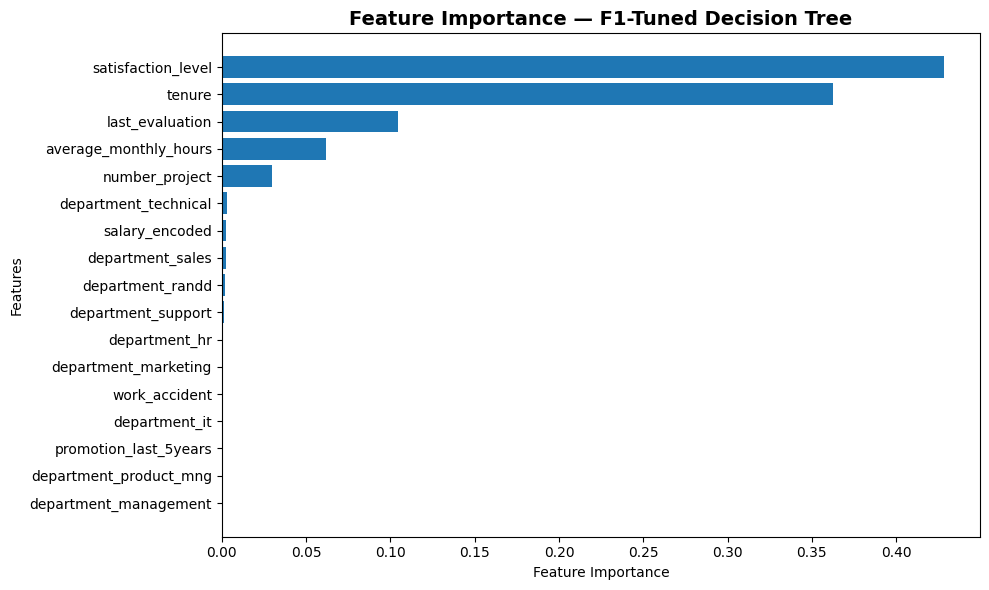

In [66]:
# ==========================================
# FEATURE IMPORTANCE — F1-TUNED DECISION TREE
# ==========================================

# Extract the final F1-optimized Decision Tree
final_f1_tree = tuned_tree_f1_cv.best_estimator_

# Create a DataFrame of feature importances
feature_importance = pd.DataFrame({
    "Feature": X_tr.columns,
    "Importance": final_f1_tree.feature_importances_
})

# Sort features by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display feature importance values
display(feature_importance)

# Plot feature importance
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title(
    "Feature Importance — F1-Tuned Decision Tree",
    fontsize=14,
    fontweight="bold"
)

# Put the most important feature at the top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


**Dominant Factors:** satisfaction_level and tenure hold nearly all the predictive weight in this F₁-Tuned Decision Tree.

**Minor Factors:** number_project carries a small fraction of weight (~0.029), followed by department variables and evaluation metrics which have negligible impact.

**Zero-Impact Features:** Fields like promotion_last_5years and department_management have an exact score of 0.000000e+00, meaning they were completely ignored during optimization splits.

# 3. Conclusion

**1. Summary of Model Performance**

Three Decision Tree configurations were built and evaluated on this employee turnover problem:

| Metric    | Untuned Baseline | Recall-Tuned (`refit='recall'`) | F1-Tuned (`refit='f1'`) |
|-----------|:---:|:---:|:---:|
| Accuracy  | 97.08% | 76.91% | **97.54%** |
| Precision | 89.42% | 41.50% | **91.65%** |
| Recall    | 93.47% | **95.73%** | 93.72% |
| F1-Score  | 91.40% | 57.90% | **92.67%** |

The **F1-tuned model** (`max_depth=10, max_features=None, min_samples_leaf=1, min_samples_split=2`) is the strongest all-around performer, edging out the untuned baseline on every metric. On the test set it correctly identifies 1,967 of 2,001 employees who stayed and 373 of 398 employees who left, misclassifying only 59 of 2,399 total cases (34 false alarms, 25 missed departures).

The **recall-tuned model** (`max_depth=4, max_features='sqrt', min_samples_leaf=1, min_samples_split=2`) demonstrates the opposite end of the tradeoff: it catches slightly more true leavers (a 2.26-point recall gain) but only by flagging 537 stable employees as false alarms — a 47.9-point collapse in precision. This model is not recommended for deployment; it was built deliberately to illustrate what happens when a grid search optimizes a single metric in isolation on an imbalanced target.

**2. Recommended Model**

The **F1-tuned Decision Tree** is the model recommended for deployment. It preserves the untuned baseline's strong recall (93.72% vs. 93.47%) while meaningfully improving precision (91.65% vs. 89.42%), meaning HR can act on its flight-risk alerts with high confidence without triggering an unmanageable volume of false alarms.

**3. Key Drivers of Turnover**

Across both tuned models, the same small set of features dominates the tree's decision logic:

- **satisfaction_level** (importance ≈ 0.428) — by far the strongest predictor; the root split of the tree occurs at `satisfaction_level ≤ 0.465`.
- **tenure** (≈ 0.362) — the second major driver; both branches of the root split immediately divide again on a 4.5-year tenure threshold.
- **last_evaluation** (≈ 0.105) and **average_monthly_hours** (≈ 0.062) — secondary indicators of workload intensity and performance pressure that fine-tune predictions within the satisfaction/tenure groups.
- **number_project** (≈ 0.030) contributes a small amount of additional signal.
- Salary, department, work accidents, and promotion history each contribute negligibly (individually and combined, well under 3% of total importance), and several features (`promotion_last_5years`, `department_management`, `department_product_mng`) were not used by the model at all.

**4. Business Implications**

- Retention efforts should prioritize **satisfaction** and **tenure milestones** over compensation or department-level interventions — the model finds these to be the dominant, and largely independent, axes along which turnover occurs.
- The interaction between satisfaction and tenure is not linear: the tree's deeper splits show that dissatisfaction manifests differently depending on how long an employee has been at the company, which is exactly the kind of interaction effect a linear model (Logistic Regression) is structurally unable to capture — consistent with the large performance gap observed between the two model families earlier in this analysis.
- Workload metrics (`last_evaluation`, `average_monthly_hours`, `number_project`) function as secondary risk amplifiers rather than primary drivers, and are most useful for fine-tuning *which* dissatisfied or newly-tenured employees are highest-risk.

**5. Next Steps**

- Evaluate Random Forest, AdaBoost, Gradient Boosting, and XGBoost against this same train/test split, per the original project scope, to confirm whether ensemble methods offer further gains over a single Decision Tree.
- Consider a cost-weighted custom scorer (e.g., via `make_scorer`) that reflects the actual relative cost of a missed departure vs. a false alarm, rather than defaulting to `'recall'` or `'f1'`, to make the tuning objective more faithful to the real business tradeoff.